In [1]:
import torch
import ray
import sys, os
from typing import Optional, Union, List
import multiprocessing
import numpy as np
#import faiss
import mdtraj as md
import matplotlib.pyplot as plt
from seaborn import kdeplot

from writhe_tools.md_tools import (traj_slice, Rg, ResidueDistances,
                                   calc_sa, tangent_corr, bending_energy,
                                   get_residues, to_distance_matrix, to_contacts)

from writhe_tools.md_tools import curvature_menger as curvature
from writhe_tools.utils import lsdir, load_dict, combinations, save_dict, load_dict, group_by, reindex_list, Timer
from writhe_tools.writhe import Writhe, window_average, to_laplacian
from writhe_tools.plots import (subplots_proj2d, subplots_fes2d, lineplot1D,
                                box_plot, plot_distance_matrix, build_matrix_boxplot_grid,
                                build_grid_plot, annotated_matrix_plot, fes2d, proj2d)
from writhe_tools.tcca import tCCA
from writhe_tools.stats import pca, standardize, get_extrema, MaxEntropyReweight, std, mean, rmse, cov

from tools import block_error, ci_filter







helix_pdb = '/data/writhe/actr/actr.helix.pdb'
obs_path = '/data/top_complexity/observables/actr'
exp_cs_file = '/data/top_complexity/observables/actr/exp_cs.dat'

names = ['a99',
         'CALVADOS',
         'bAIes',
         'BioEMU',
         'STARLING',
         #'Coil',
        ]
labels = ['a99SB-disp',
          'CALVADOS',
          'bAIes',
          'bioemu', 
          'STARLING',
          #'coil',
         ]
need_slice = [True, False, True, True, True, True]
colors = ['steelblue',
          'orange',
          'olivedrab',
          'indianred',
          'gray',
          #'purple',
         ]

protein_names = [ r'A$\beta$40', 'ACTR', r'$\alpha$Synuclein']

helix_pdbs = ['/data/r1r2/kaush/ab40/Ab40_helix.pdb', '/data/writhe/actr/actr.helix.pdb']

weights_files = [f'{obs_path}/{i}' for i in ['weights_cs', 'weights_pre', 'weights_all']]



from writhe_tools.plots import fes2d, proj2d


# n_classes = len(colors)
from matplotlib.colors import ListedColormap, BoundaryNorm
cmap = ListedColormap(colors)
bounds = np.arange(0, len(colors) , 1)          # [-0.5, 0.5, 1.5, ...]
norm = BoundaryNorm(bounds, cmap.N)

[writhe_tools] ⏭️ Skipping 'graph_utils' (missing: torch_geometric)
[writhe_tools] 👉 To enable this module, install: pip install writhe-tools[graph]


In [2]:
files = { 'ab40' : {'pdb' : [
                    "/data/top_complexity/a99/Ab40.pdb",
                    "/data/top_complexity/calvados2_ensembles/Ab40/Ab40_converted.pdb",
                    "/data/top_complexity/bAIes/Ab40.pdb",
                    "/data/top_complexity/bioemu_ensembles/Ab40/topology_ready.pdb",
                    "/data/top_complexity/starling/ab40/ab40_starling_all.pdb",
                    #"/data/top_complexity/bAIes/Ab40.pdb"
                    
                    
                   ],
           'dcd' : ["/data/top_complexity/a99/Ab40-a99SBdisp-Traj.dcd",
                     "/data/top_complexity/calvados2_ensembles/Ab40/Ab40_converted.xtc",
                     "/data/top_complexity/bAIes/traj_Ab40_bAIes.xtc",
                     "/data/top_complexity/bioemu_ensembles/Ab40/samples_ready.xtc",
                     "/data/top_complexity/starling/ab40/ab40_starling_all.xtc",
                     #"/data/top_complexity/bAIes/traj_Ab40_coil.xtc",
                   ]  
           
          },
    
    
    
    
    'actr' : {'pdb' : [
                    "/data/top_complexity/a99/actr.pdb",
                    "/data/top_complexity/calvados2_ensembles/ACTR/ACTR_converted.pdb",
                    "/data/top_complexity/bAIes/ACTR.pdb",
                    "/data/top_complexity/bioemu_ensembles/ACTR/topology_ready.pdb",
                    "/data/top_complexity/starling/actr/actr_starling_all.pdb",
                    #"/data/top_complexity/bAIes/ACTR.pdb"
    ]
        ,
           'dcd' : [
                   "/data/top_complexity/a99/ACTR-a99SBdisp-Traj.dcd",
                   "/data/top_complexity/calvados2_ensembles/ACTR/ACTR_converted.xtc",
                   "/data/top_complexity/bAIes/traj_ACTR_bAIes.xtc",
                   "/data/top_complexity/bioemu_ensembles/ACTR/samples_ready.xtc",
                   "/data/top_complexity/starling/actr/actr_starling_all.xtc",
                   #"/data/top_complexity/bAIes/traj_ACTR_coil.xtc"
        ]
          },
 

 'asyn' : {'pdb' : ["/data/top_complexity/a99/asyn_full_lig47_trunc.protein.pdb",  
                    "/data/top_complexity/calvados2_ensembles/asyn/asyn_converted.pdb",
                    "/data/top_complexity/bAIes/asyn.pdb",
                    "/data/top_complexity/bioemu_ensembles/asyn/topology_ready.pdb",
                    "/data/top_complexity/starling/asyn/asyn_starling.pdb",
                    #"/data/top_complexity/bAIes/asyn.pdb",
                   ],
           'dcd' : ["/data/top_complexity/a99/asyn_apo_full.dcd",
                    "/data/top_complexity/calvados2_ensembles/asyn/asyn_converted.xtc",
                    "/data/top_complexity/bAIes/traj_asyn_bAIes.xtc",
                    "/data/top_complexity/bioemu_ensembles/asyn/samples_ready.xtc",
                    "/data/top_complexity/starling/asyn/asyn_starling.xtc",
                    #"/data/top_complexity/bAIes/traj_asyn_coil.xtc"
                           
           ]

     
 }
 
}

In [3]:
all_writhes = []
for p, d in zip(*list(files['ab40'].values())):
    traj = md.load(d, top=p, atom_indices=md.load(p).top.select('name CA')).center_coordinates()
    writhe = Writhe(traj.xyz)
    all_writhes.append(writhe.compute_writhe(1, cuda=False)['writhe_features'])
    
#save_dict('asyn_xyz.pkl', xyz)

2026-02-22 10:21:11,411	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
/home/t/miniconda3/envs/writhe/lib/python3.10/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-02-22 10:21:21,875	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
2026-02-22 10:21:31,766	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
/home/t/miniconda3/envs/writhe/lib/python3.10/site-packages/mdtraj/formats/pdb/pdbfile.py:208: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(
2026-02-22 10:21:41,762	INFO worker.py:2004 -- Sta

In [7]:
xyz = []
for p, d in zip(*list(files['asyn'].values())):
    xyz.append(md.load(d, top=p, atom_indices=md.load(p).top.select('name CA')).center_coordinates().xyz)
save_dict('asyn_xyz.pkl', xyz)
    

/home/t/miniconda3/envs/writhe/lib/python3.10/site-packages/mdtraj/formats/pdb/pdbfile.py:208: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


In [3]:
from scipy.linalg import svd, eigh
def stride_indices(n: int, m: int) -> np.ndarray:
    """
    Return m monotonically increasing frame indices in [0, n-1],
    roughly evenly spaced, including endpoints (0 and n-1 when m>=2).
    """
    n = int(n)
    m = int(m)

    if n < 1:
        raise ValueError("n must be >= 1")
    if m < 1:
        raise ValueError("m must be >= 1")
    if m == 1:
        return np.array([0], dtype=np.int64)
    if m > n:
        raise ValueError("m cannot exceed n if you require unique frames")

    k = np.arange(m, dtype=np.int64)
    return (k * (n - 1)) // (m - 1)

from writhe_tools.stats import std

def low_rank_lda(Xs: list, mus: list, weights = None, eps=1e-8):
    
    lengths = np.fromiter(map(len, Xs), int)
    X = np.concatenate([x - mu for x, mu in zip(Xs, mus)], 0)
    sigma = std(X)
    sigma[np.isclose(sigma, 0)] = 1
    X /= sigma
    s, Vt = svd(X / (lengths.sum() - len(Xs)) ** (1/2) if weights is None else X * np.sqrt(weights),
                full_matrices=False)[1:]
    keep = s > eps
    Vinv = (1 / sigma[:, None]) * Vt[keep].T / s[keep]
    M = np.stack(mus)
    mu_star = M.mean(0)
    M -= mu_star
    U = svd(M @ Vinv, full_matrices=False)[-1][:2].T

    return np.array_split((np.concatenate(Xs, 0) - mu_star) @ Vinv @ U, np.cumsum(lengths)[:-1])
    

def gaussian_comparison(Xs: np.ndarray,
                        n: int = 20000,
                        weights: list = None,
                        low_rank: bool = False
                       ):

    
    
    xs = np.stack([x[stride_indices(len(x), n)] for x in Xs])
    ws = np.stack([w[stride_indices(len(w), n)] for w in weights]) if weights is not None else None
    if ws is not None:
        ws = ws / ws.sum(1, keepdims=True)  # renormalize after striding (each ensemble sums to 1)

    mus = (xs * ws[..., None]).sum(1) if ws is not None else xs.mean(1)
    mu_star = mus.mean(0, keepdims=True)

    Cs = np.stack([cov(x, weights=w) for x, w in zip(xs, ws)]) if ws is not None else np.stack([cov(x) for x in xs])
    C = Cs.mean(0)

    K = xs.shape[0]

    ## insert low rank approach here
    if low_rank:
        Zs = low_rank_lda(xs, mus, weights)
    else:
        B = mus - mu_star                    # (K,d)
        S_B = (B.T @ B) / K 
        s, V = eigh(S_B, C)
        sort = s.argsort()[::-1]
        V = V[:, sort[:2]]
        Zs = np.stack([(x - mu_star) @ V for x in xs])



    # ---- (1) directional similarity: fast shared-Gaussian scoring ----
    W = np.linalg.solve(C, mus.T)                    # columns are C^{-1} mu_j
    b = -0.5 * np.einsum("kd,dk->k", mus, W)         # -1/2 mu_j^T C^{-1} mu_j  (equal priors -> no log pi)

    P = []
    for x in xs:
        logits = x @ W + b                           # (n, K)
        logits = logits - logits.max(1, keepdims=True)
        ps = np.exp(logits)
        ps = ps / ps.sum(1, keepdims=True)           # (n, K)
        P.append(ps.mean(0))                         # (K,)
    P = np.stack(P)                                  # (K, K)

    # ---- (2) mean distance matrix ----
    G = mus @ W                                      # G_ij = mu_i^T C^{-1} mu_j
    g = np.diag(G)
    D2 = g[:, None] + g[None, :] - 2.0 * G
    D = np.sqrt(np.maximum(D2, 0.0))                 # (K, K)

    # ---- (3) coverage matrix ----
    
    Cvg = np.zeros((K, K), dtype=np.float64)

    r = np.empty(K, dtype=np.float64)
    I = np.eye(xs.shape[-1])
    for j in range(K):
        Sj_inv = np.linalg.pinv(Cs[j] + 1e-6 * I, 1e-12)
    
        # squared Mahalanobis for *all* datasets i against (mu_j, Sigma_j) in one shot
        C_all = xs - mus[j]                                   # (K,n,d) broadcast
        d2_all = np.einsum("knd,dd,knd->kn", C_all, Sj_inv, C_all)  # (K,n)
    
        r[j] = np.quantile(d2_all[j], 0.95)                   # threshold from j's own row
        Cvg[:, j] = (d2_all <= r[j]).mean(axis=1)             # coverage for all i

    

    
    return [P, D, Cvg, Zs]

In [4]:
from tools import ci_filter
import warnings

warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in log",
    category=RuntimeWarning,
)

import warnings
warnings.filterwarnings(
    "ignore",
    message=r"Adding colorbar to a different Figure.*",
    category=UserWarning,
)

# ... then run the code that triggers it


In [ ]:
def sigmoid(x, shift=1.2, scale=6):
    return 1 - 1 / (1 + np.exp(-scale * (x - shift)))
x = np.linspace(0, 5, 1000)
plt.figure(figsize=(4, 2))
plt.plot(x, sigmoid(x))

In [5]:
import numpy as np
import ray


# ============================================================
# Pairwise distances (NumPy only, no (n,n,d) tensor)
# ============================================================

def pairwise_distances_numpy(x: np.ndarray,
                             squared: bool = False,) -> np.ndarray:
    """
    Euclidean pairwise distances using:
        ||x-y||^2 = ||x||^2 + ||y||^2 - 2 x·y
    """
    if x.ndim != 2:
        raise ValueError("data must have shape (n_samples, n_features)")

    x2 = (x * x).sum(axis=1)                      # (n,)
    d2 = x2[:, None] + x2[None, :] - 2.0 * (x @ x.T)
    np.maximum(d2, 0.0, out=d2)
    np.fill_diagonal(d2, 0.0)

    if squared:
        return d2

    return d2 ** (1/2)


# ============================================================
# KMeans++ init (NumPy only)
# ============================================================

def _kmeanspp_init_numpy(x: np.ndarray,
                         n_clusters: int,
                         rng: np.random.Generator) -> np.ndarray:
    n, d = x.shape
    k = int(n_clusters)

    centers = np.empty((k, d), dtype=x.dtype)

    # first center
    i0 = int(rng.integers(0, n))
    centers[0] = x[i0]

    diff = x - centers[0]
    min_d2 = (diff * diff).sum(axis=1)

    for j in range(1, k):
        s = float(min_d2.sum())
        if (s <= 0.0) or (not np.isfinite(s)):
            ij = int(rng.integers(0, n))
        else:
            ij = int(rng.choice(n, p=min_d2 / s))

        centers[j] = x[ij]

        diff = x - centers[j]
        d2_new = (diff * diff).sum(axis=1)
        np.minimum(min_d2, d2_new, out=min_d2)

    return centers


# ============================================================
# KMeans (NumPy only, no one-hot matrix)
# ============================================================

def kmeans_numpy(x: np.ndarray,
                 n_clusters: int,
                 n_init: int = 10,
                 max_iter: int = 100,
                 tol: float = 1e-4,
                 random_state: int = 0):
    """
    Pure NumPy KMeans with k-means++ init.

    Returns
    -------
    labels : (n,) int array
    centers : (k, d) float array
    inertia : float
    """
    if x.ndim != 2:
        raise ValueError("data must have shape (n_samples, n_features)")

    n, d = x.shape
    k = int(n_clusters)

    if k < 2:
        raise ValueError("n_clusters must be >= 2")
    if k > n:
        raise ValueError("n_clusters cannot exceed number of samples")

    x2 = (x * x).sum(axis=1)
    rng_master = np.random.default_rng(random_state)

    best_labels = None
    best_centers = None
    best_inertia = np.inf

    for _ in range(int(n_init)):
        seed = int(rng_master.integers(0, 2**31 - 1))
        rng = np.random.default_rng(seed)

        centers = _kmeanspp_init_numpy(x, k, rng)
        labels_prev = None

        for _ in range(int(max_iter)):
            # assignment step: (n, k) matrix is the unavoidable core object
            c2 = (centers * centers).sum(axis=1)                    # (k,)
            d2 = x2[:, None] + c2[None, :] - 2.0 * (x @ centers.T)  # (n, k)
            np.maximum(d2, 0.0, out=d2)

            labels = np.argmin(d2, axis=1)

            if labels_prev is not None and np.array_equal(labels, labels_prev):
                break

            # update step without one-hot
            sums = np.zeros((k, d), dtype=x.dtype)
            np.add.at(sums, labels, x)

            counts = np.bincount(labels, minlength=k)
            centers_new = centers.copy()

            nonempty = counts > 0
            centers_new[nonempty] = sums[nonempty] / counts[nonempty, None]

            # reseed empty clusters to farthest assigned points
            if np.any(~nonempty):
                assigned_d2 = d2[np.arange(n), labels].copy()
                empty_ids = np.flatnonzero(~nonempty)
                for cid in empty_ids:
                    idx = int(np.argmax(assigned_d2))
                    centers_new[cid] = x[idx]
                    assigned_d2[idx] = -1.0

            shift2 = ((centers_new - centers) ** 2).sum(axis=1)
            centers = centers_new
            labels_prev = labels

            if shift2.size and float(shift2.max()) <= (tol * tol):
                break

        # final assignment for this init
        c2 = (centers * centers).sum(axis=1)
        d2 = x2[:, None] + c2[None, :] - 2.0 * (x @ centers.T)
        np.maximum(d2, 0.0, out=d2)

        labels = np.argmin(d2, axis=1)
        inertia = float(d2[np.arange(n), labels].sum())

        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
            best_centers = centers.copy()

    return best_labels, best_centers, best_inertia


# ============================================================
# Silhouette score from precomputed distances (NumPy only)
# No one-hot matrix, no giant D @ M
# ============================================================

def silhouette_score_precomputed_numpy(D: np.ndarray,
                                       labels: np.ndarray) -> float:
    """
    Exact silhouette score from precomputed distance matrix.
    """
    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise ValueError("distance_matrix must be square (n, n)")

    n = D.shape[0]
    labels = np.asarray(labels)
    if labels.ndim != 1 or labels.shape[0] != n:
        raise ValueError("labels must have shape (n,)")

    # normalize labels -> 0..k-1
    _, inv = np.unique(labels, return_inverse=True)

    k = int(inv.max()) + 1

    if k < 2 or k >= n:
        raise ValueError("silhouette requires 2 <= n_clusters <= n_samples - 1")

    cluster_indices = [np.flatnonzero(inv == c) for c in range(k)]
    counts = np.array([idx.size for idx in cluster_indices])

    a = np.zeros(n)             # intra-cluster mean dist
    b = np.full(n, np.inf)      # nearest other-cluster mean dist

    singleton = counts[inv] <= 1

    # loop over clusters (small k), vectorize across samples
    for c, idx in enumerate(cluster_indices):
        m = int(idx.size)
        if m == 0:
            continue

        # sum distances from every point to cluster c
        sums = D[:, idx].sum(axis=1)              # (n,)
        mean_to_c = sums / m

        # update b for points not in c
        tmp = mean_to_c.copy()
        tmp[idx] = np.inf
        np.minimum(b, tmp, out=b)

        # update a for points in c
        if m > 1:
            a[idx] = sums[idx] / (m - 1)
        else:
            a[idx] = 0.0

    denom = np.maximum(a, b)
    s = np.zeros(n)

    valid = (~singleton) & (denom > 0.0)
    s[valid] = (b[valid] - a[valid]) / denom[valid]
    s[~valid] = 0.0   # sklearn convention for singleton clusters

    return float(s.mean())


# ============================================================
# Composed NumPy score function (serializable by Ray)
# ============================================================

def score_k_numpy(distance_matrix: np.ndarray,
                  data: np.ndarray,
                  k: int,
                  n_init: int = 10,
                  max_iter: int = 100,
                  tol: float = 1e-4,
                  random_state: int = 0) -> float:
    labels, _, _ = kmeans_numpy(data,
                                n_clusters=int(k),
                                n_init=n_init,
                                max_iter=max_iter,
                                tol=tol,
                                random_state=random_state)
    return silhouette_score_precomputed_numpy(distance_matrix, labels)



# ============================================================
# Convenience wrapper (same spirit as your original)
# ============================================================

def silhouette_scores(data: np.ndarray,
                      k: "int or list",
                      parallel: bool = False,
                      n_init: int = 10,
                      max_iter: int = 100,
                      tol: float = 1e-4,
                      random_state: int = 0,
                      dtype=np.float32):
    """
    Compute silhouette score(s) for one or many k using pure NumPy KMeans + silhouette.
    Optional Ray parallelization across k.

    Returns
    -------
    if k is int:
        [k, score]
    else:
        ndarray shape (len(k), 2): columns [k, score]
    """
    if data.ndim != 2:
        raise ValueError("data must have shape (n_samples, n_features)")

    D = pairwise_distances_numpy(data, squared=False)

    # scalar path
    if np.isscalar(k):
        ki = int(k)
        return [ki, score_k_numpy(D, data, ki,
                                  n_init=n_init,
                                  max_iter=max_iter,
                                  tol=tol,
                                  random_state=random_state)]

    ks = [int(i) for i in k]

    # serial path
    if not parallel:
        scores = np.fromiter((score_k_numpy(D, data, ki,
                                            n_init=n_init,
                                            max_iter=max_iter,
                                            tol=tol,
                                            random_state=random_state + 10007 * ki)
                              for ki in ks),
                             dtype=float,
                             count=len(ks))
        return np.stack([np.array(ks, dtype=float), scores], axis=1)
    #ray.init()
    # ray path
    D_ref = ray.put(D)
    x_ref = ray.put(data)
    score_ref = ray.remote(score_k_numpy)
    scores = ray.get([score_ref.remote(D_ref, x_ref, k) for k in ks])
    ray.internal.free(D_ref)
    ray.internal.free(x_ref)
    ray.shutdown()

    
    


    return np.stack([np.array(ks, dtype=float), np.array(scores, dtype=float)], axis=1)


#silhouette_scores(np.random.rand(100 * 2).reshape(100, 2), [3, 4, 5, 6])

In [12]:
ray.shutdown()
x = np.random.rand(100 * 2).reshape(100, 2)
D = pairwise_distances_numpy(x, squared=False)
print(score_k_numpy(D, x, 5, 5))
silhouette_scores(x, [2, 3, 4 ], parallel=True)

0.4499677244647797


2026-02-22 10:31:35,846	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


prep_compute


array([[2.        , 0.41243078],
       [3.        , 0.44348495],
       [4.        , 0.47882006]])

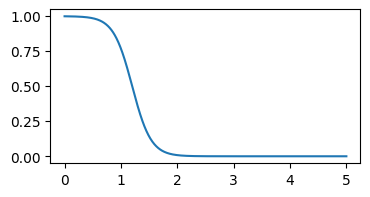

In [6]:
def sigmoid(x, shift=1.2, scale=6):
    return 1 - 1 / (1 + np.exp(-scale * (x - shift)))
x = np.linspace(0, 5, 1000)
plt.figure(figsize=(4, 2))
plt.plot(x, sigmoid(x))

In [53]:
from scipy.signal import find_peaks
def get_best_k(scores):
    k, s = scores.T
    idx = find_peaks(s)[0]
    best_k, score = k[idx][s[idx].argmax()], s[idx].max()
    return best_k, score
get_best_k(scores)

(6.0, 0.44887833255165965)

2026-02-23 13:39:18,224	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
2026-02-23 13:39:46,244	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
2026-02-23 13:40:15,539	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
2026-02-23 13:40:43,955	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
2026-02-23 13:41:12,710	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
2026-02-23 13:41:41,437	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
2026-02-23 13:42:11,638	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
2026-02-23 13:42:39,113	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
2026-02-23 13:43:04,634	INFO worker.py:2004 -- Started a local Ray instance. Vie

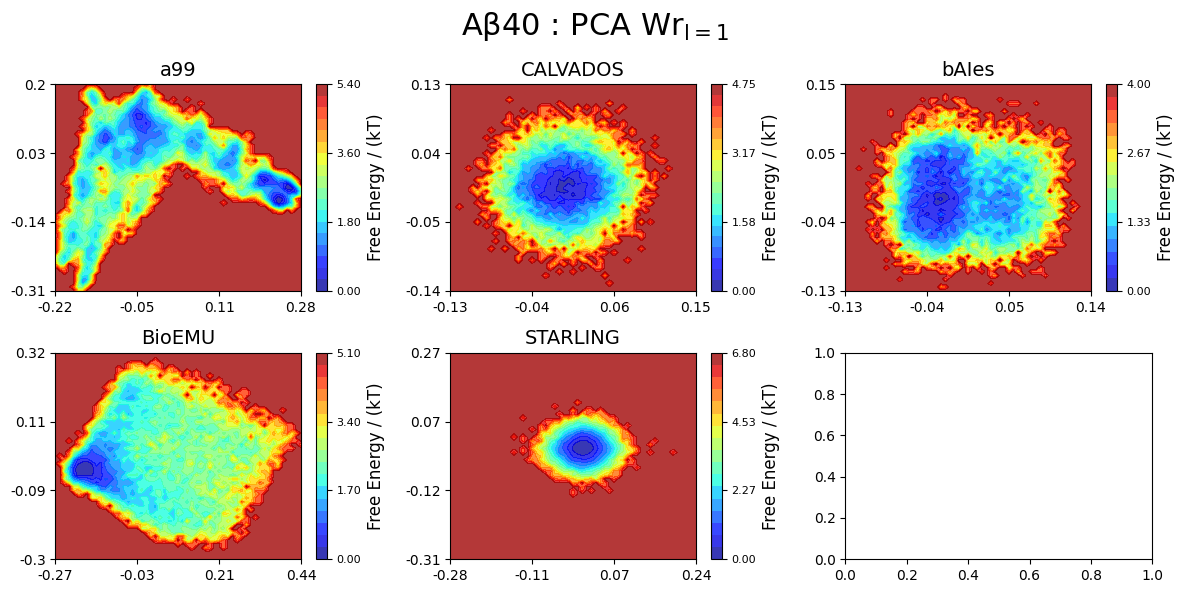

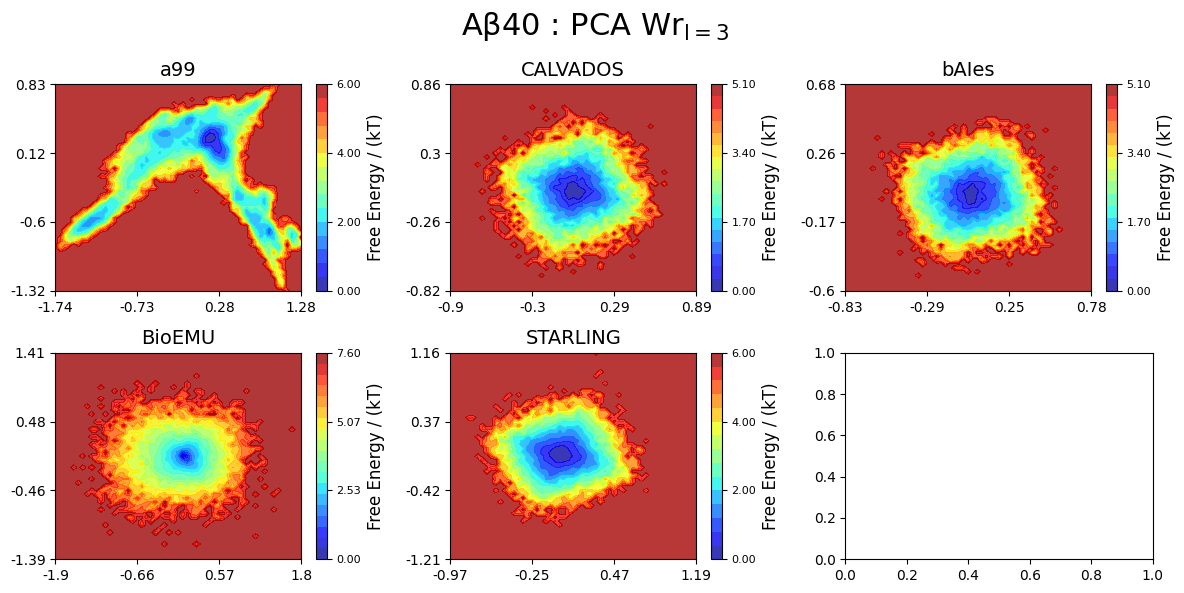

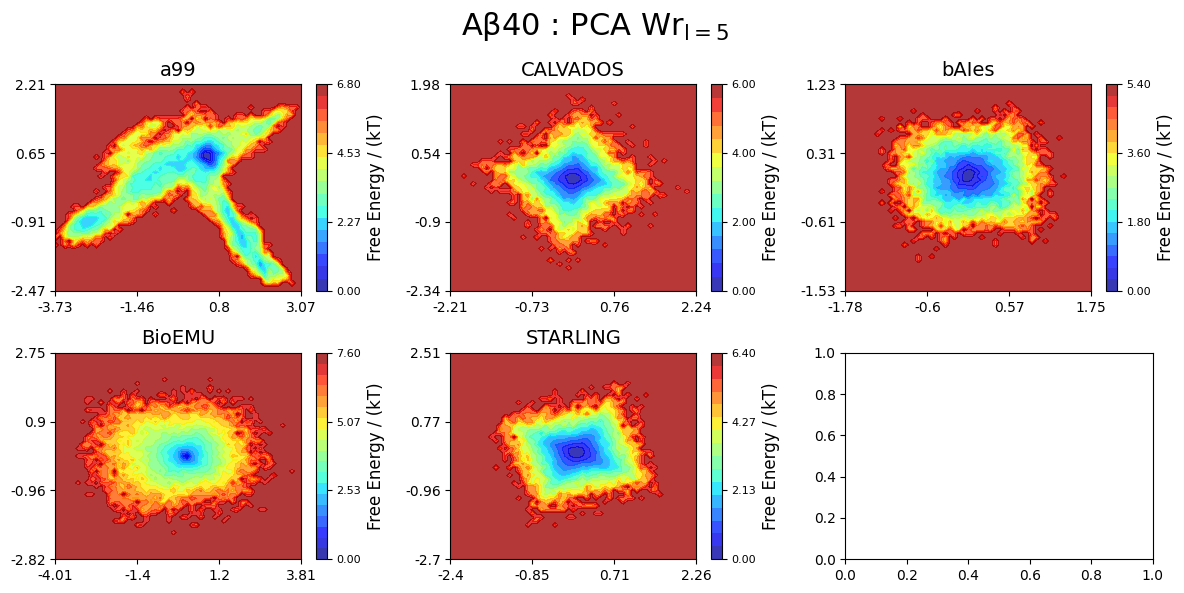

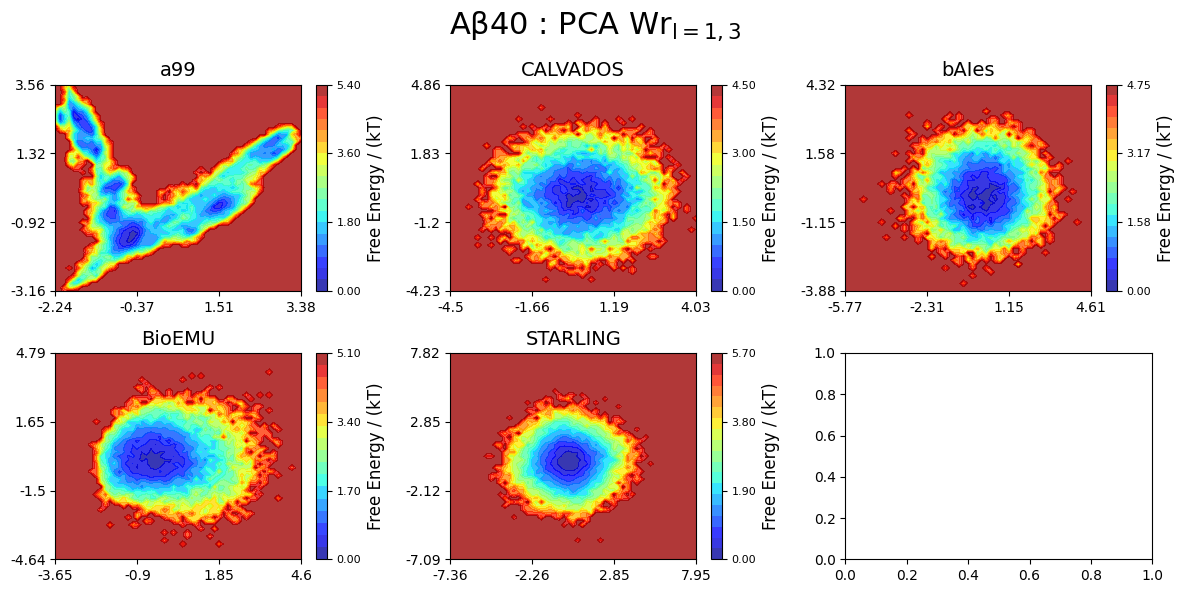

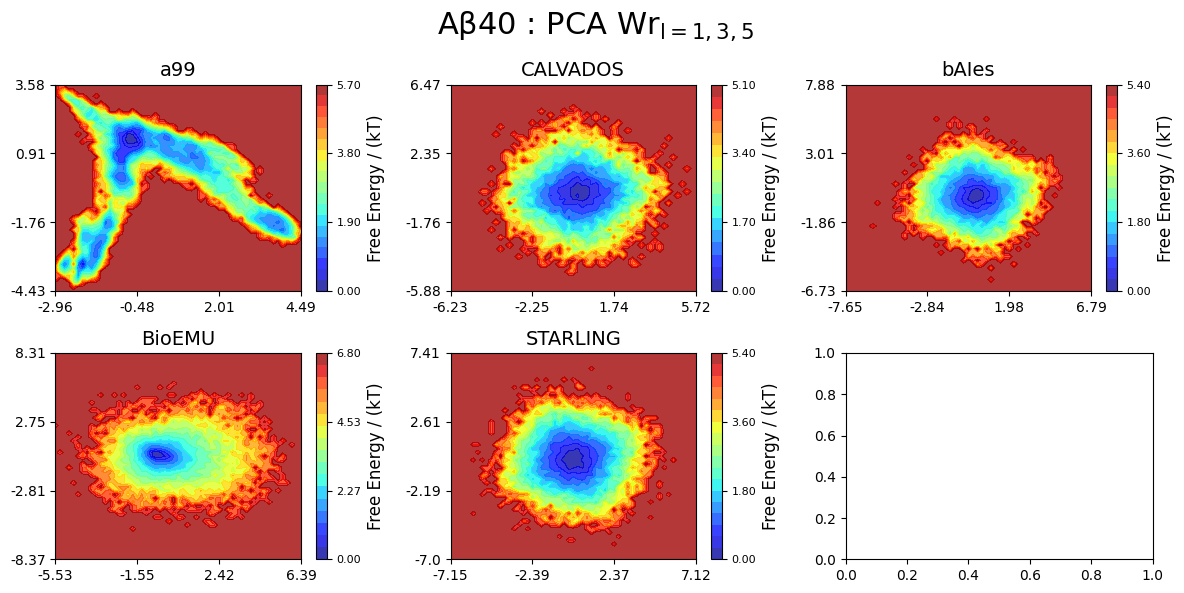

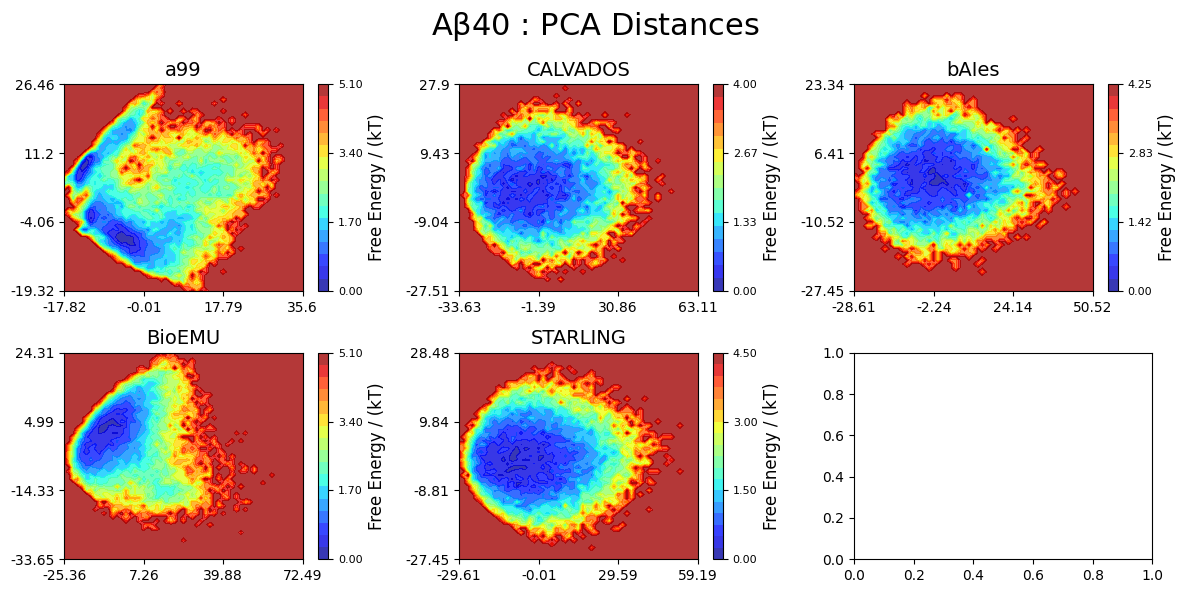

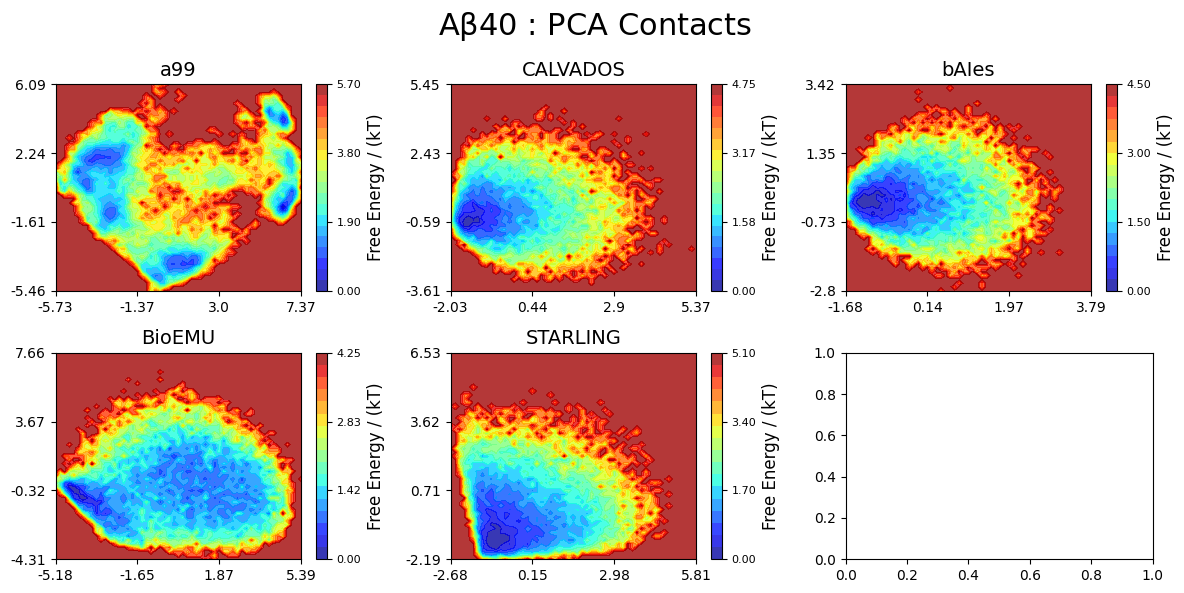

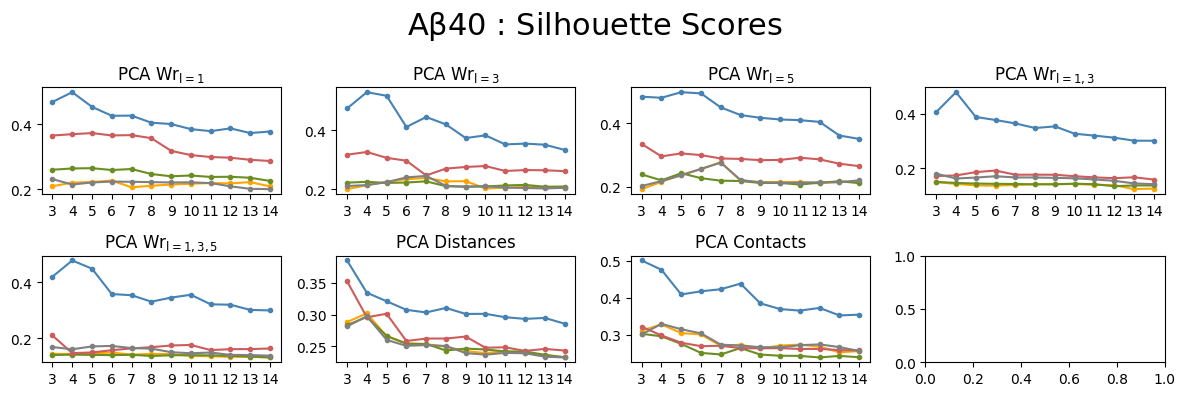

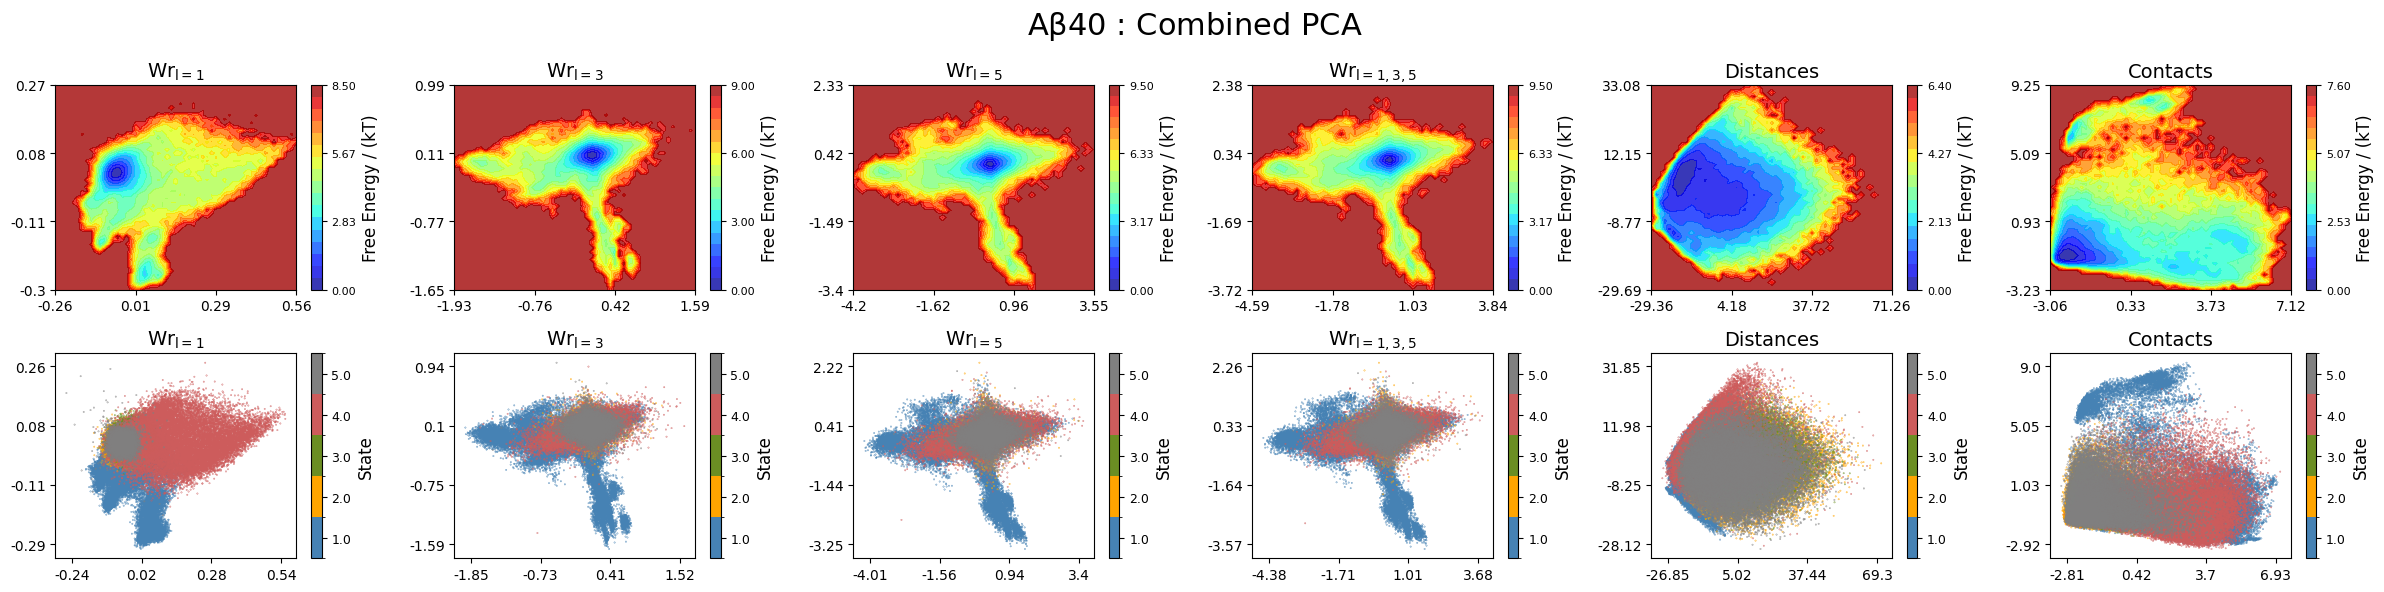

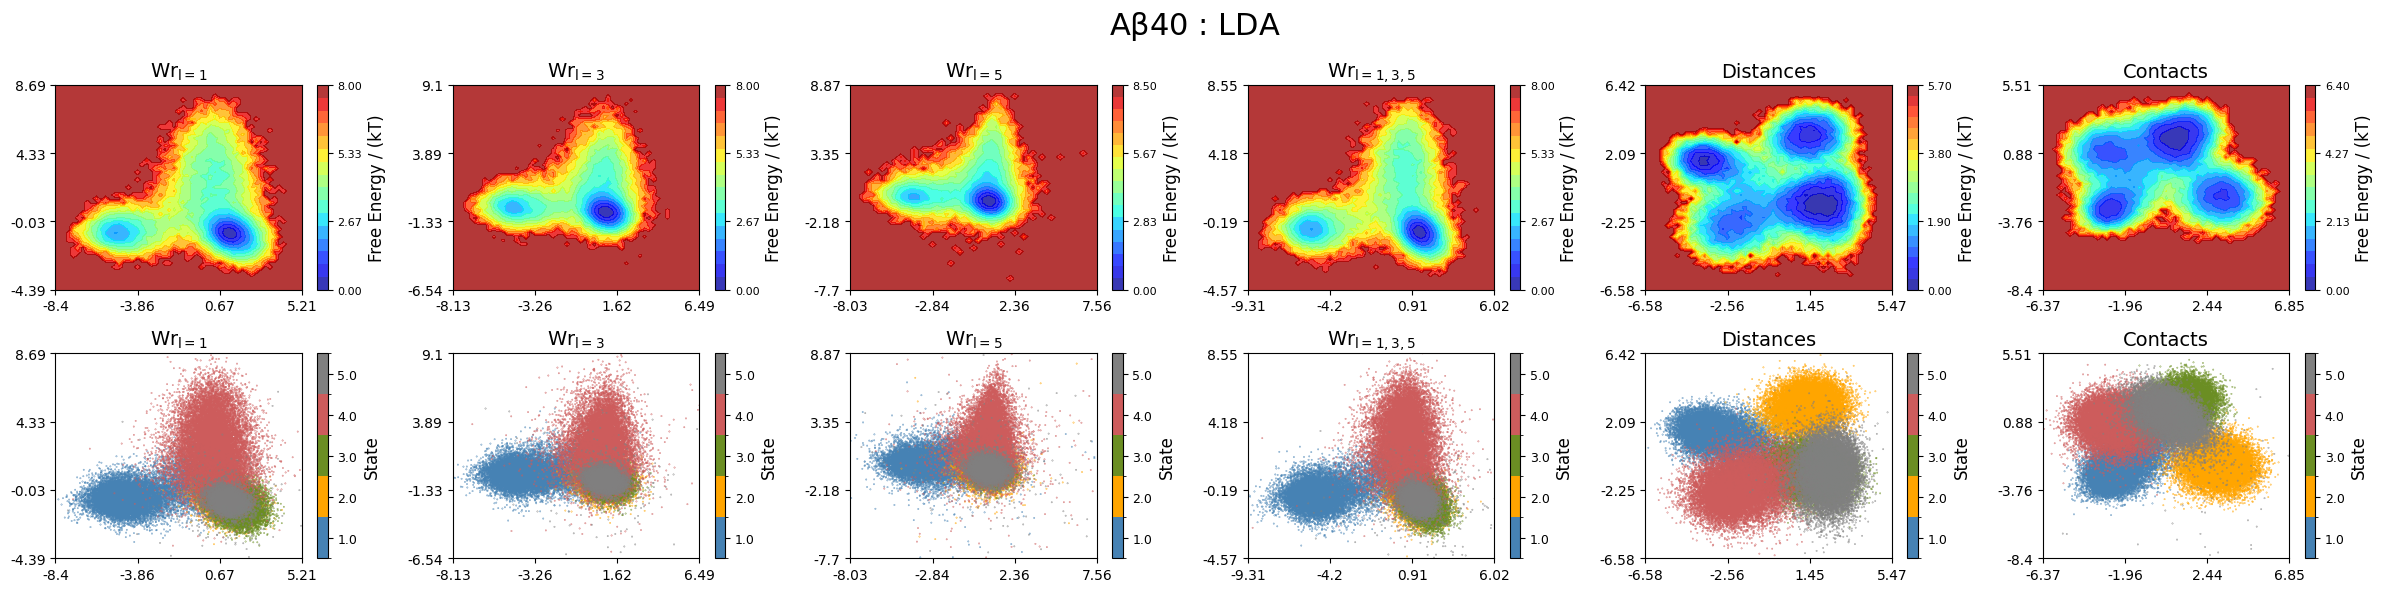

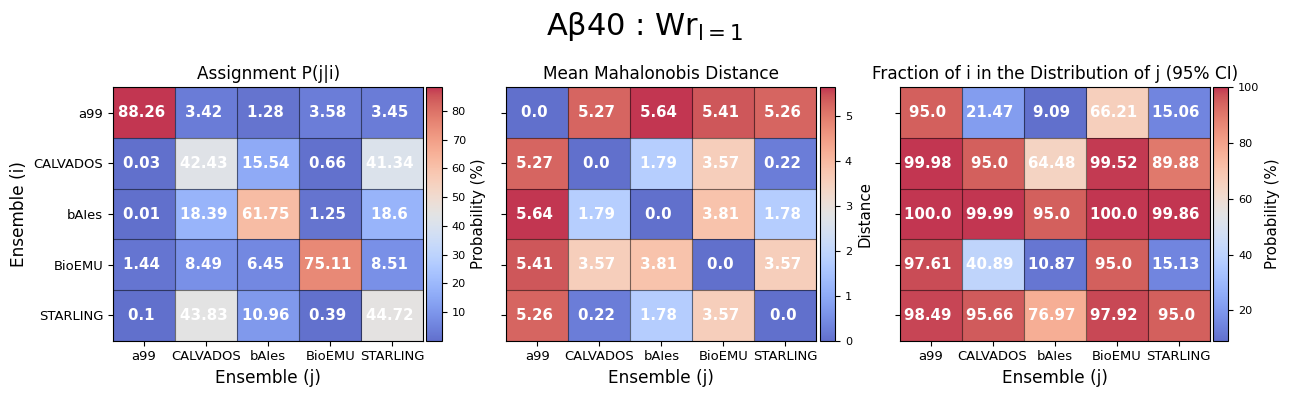

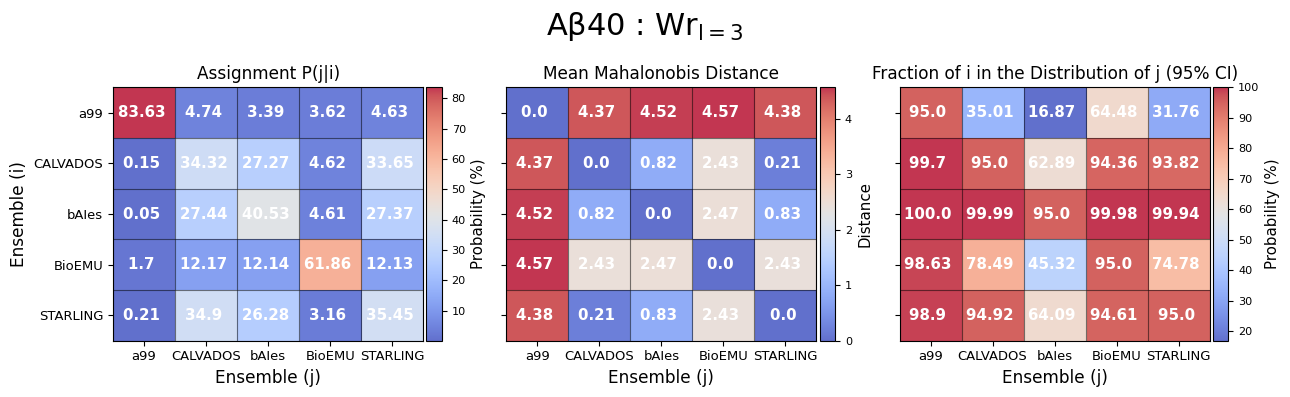

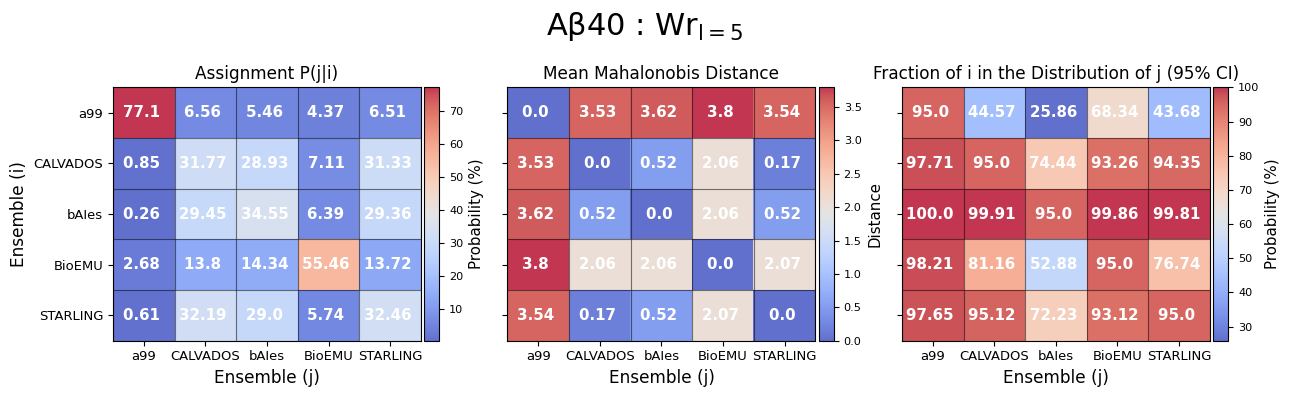

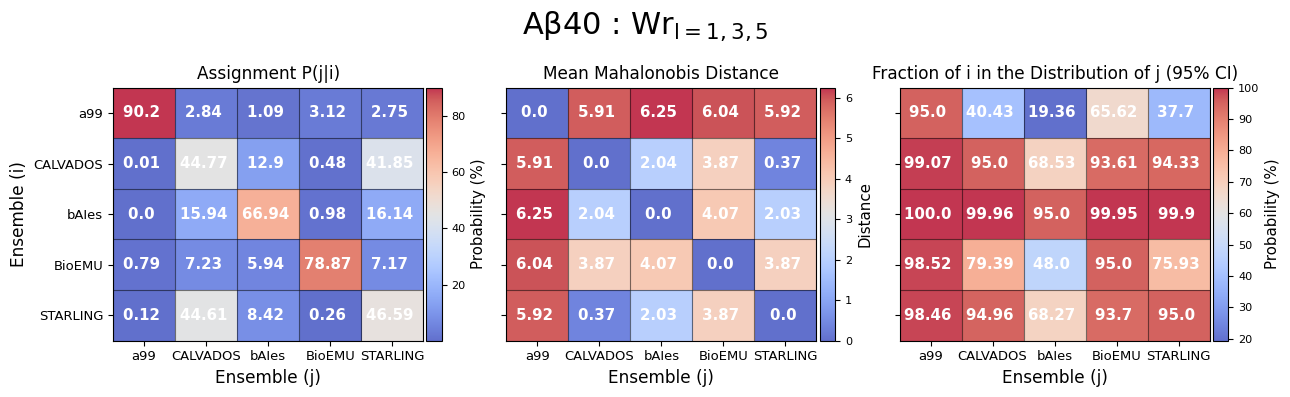

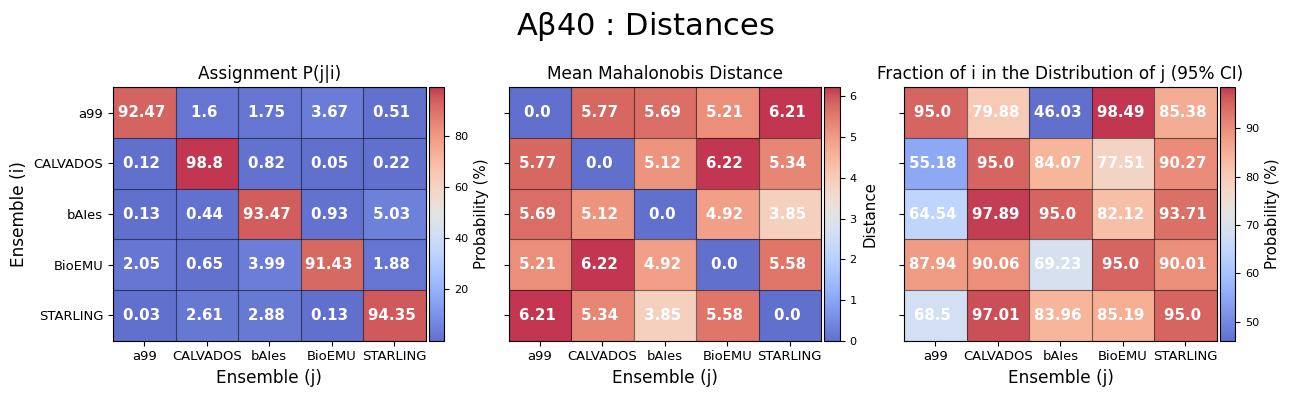

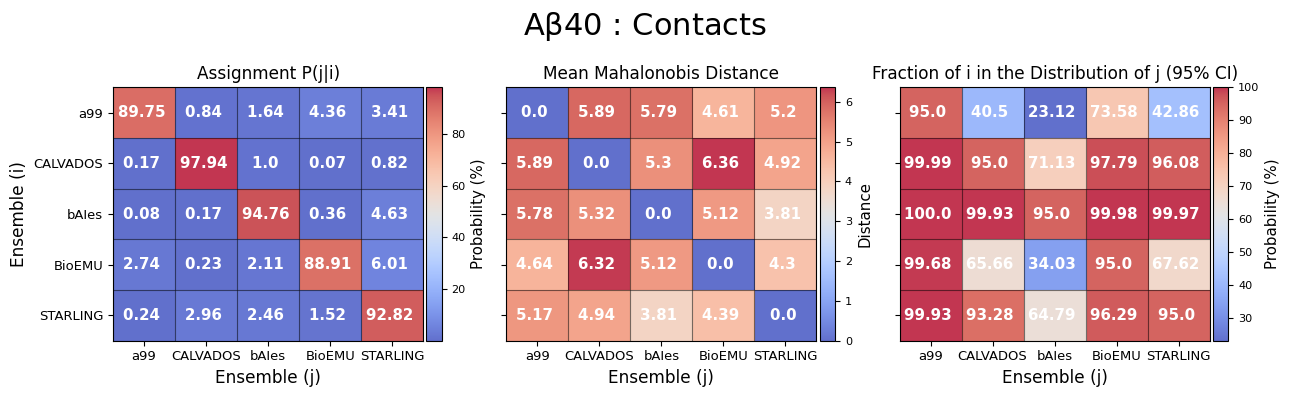

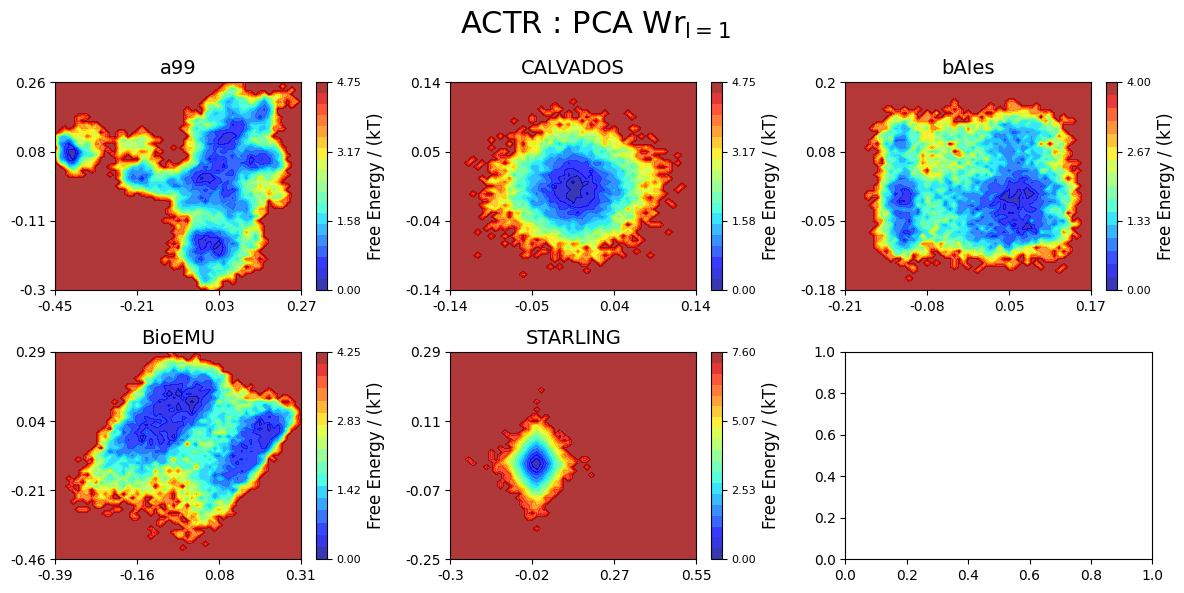

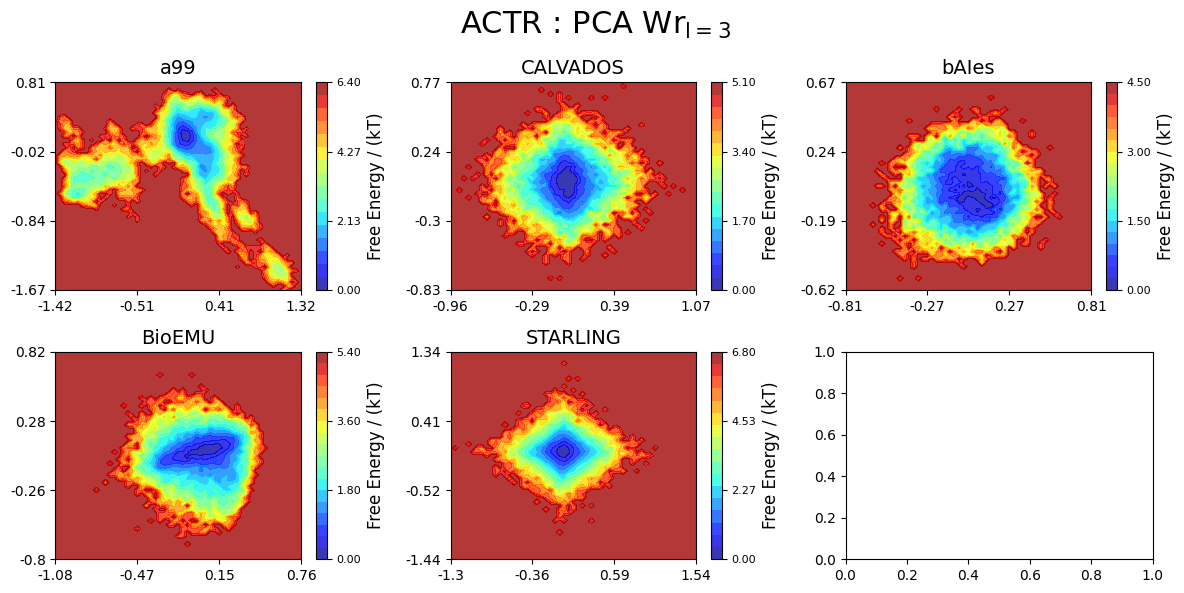

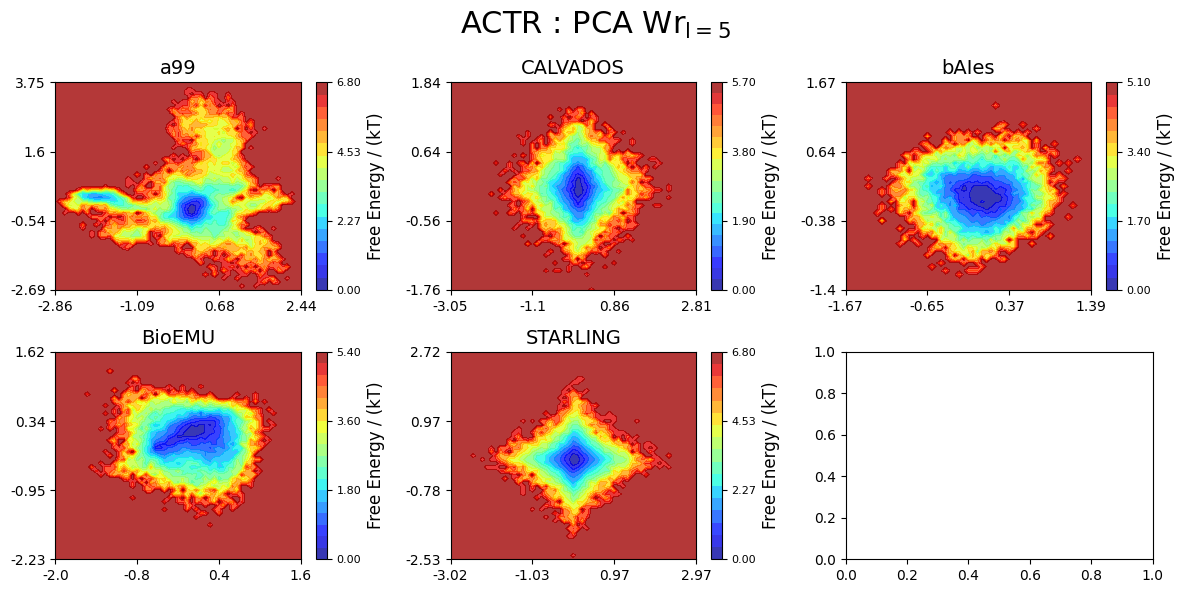

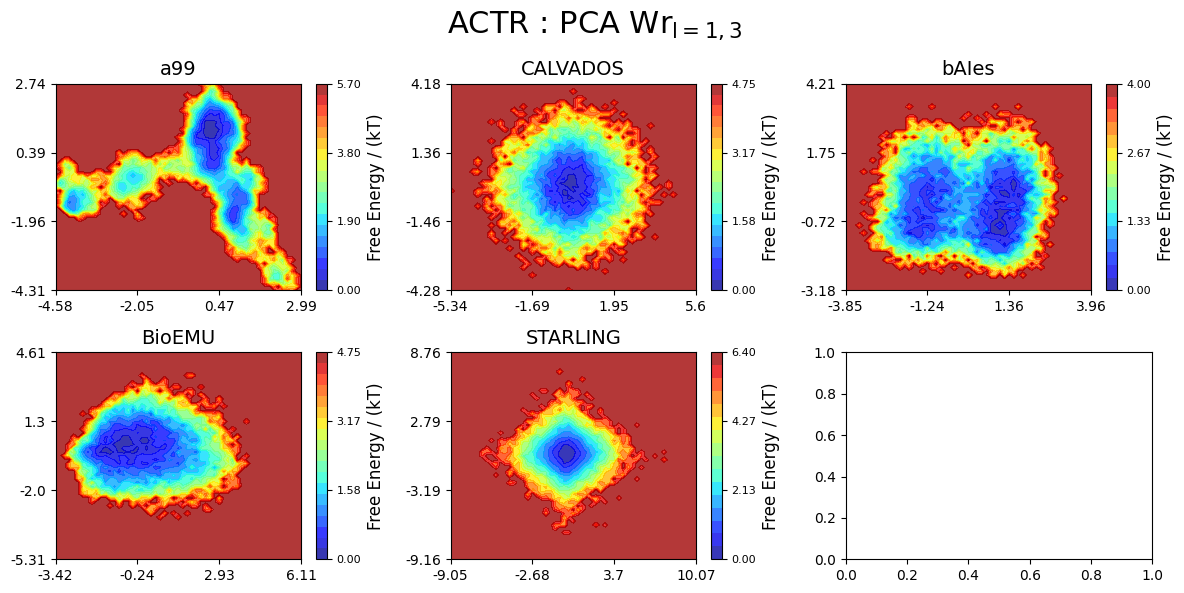

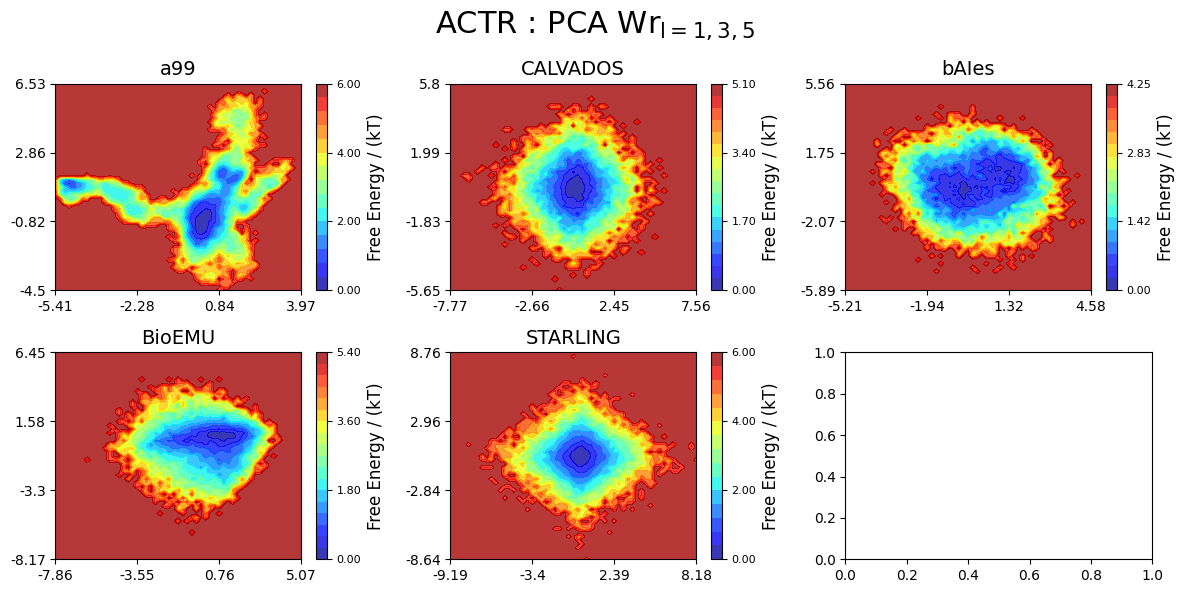

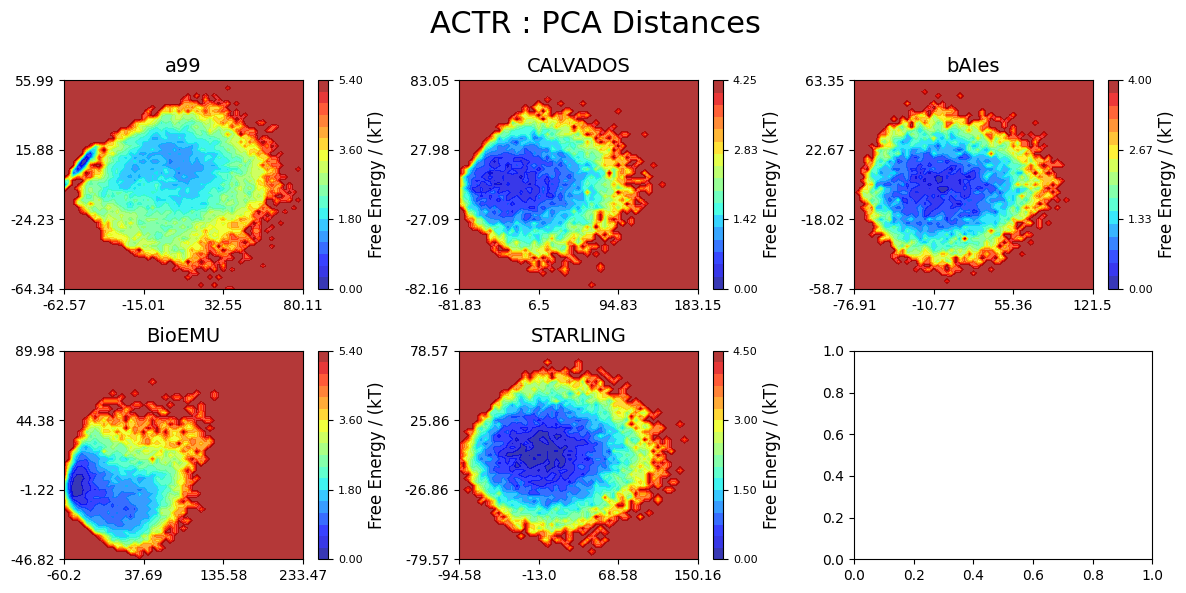

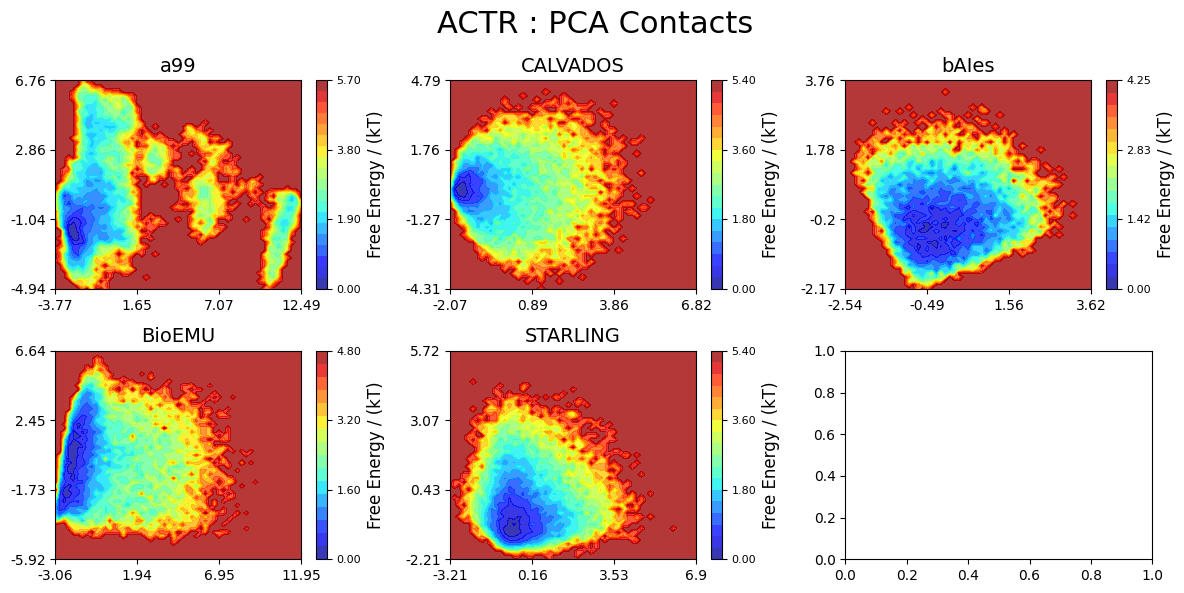

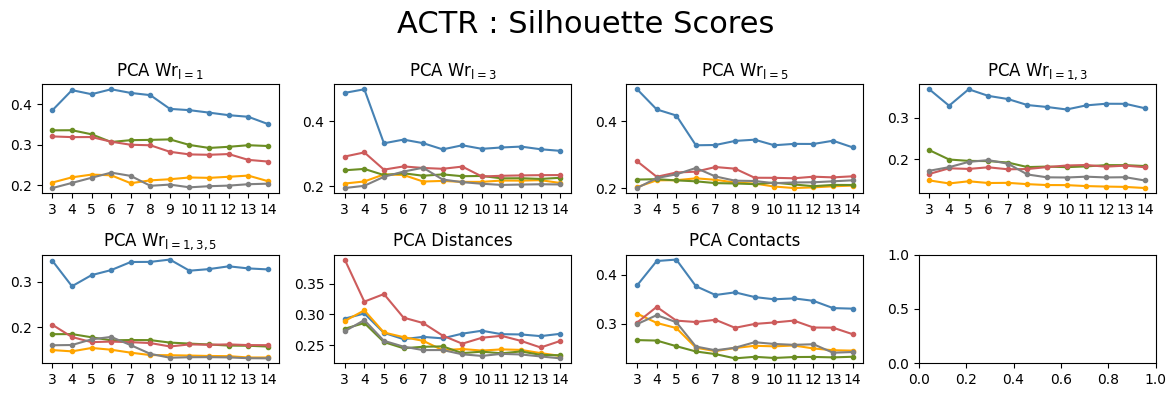

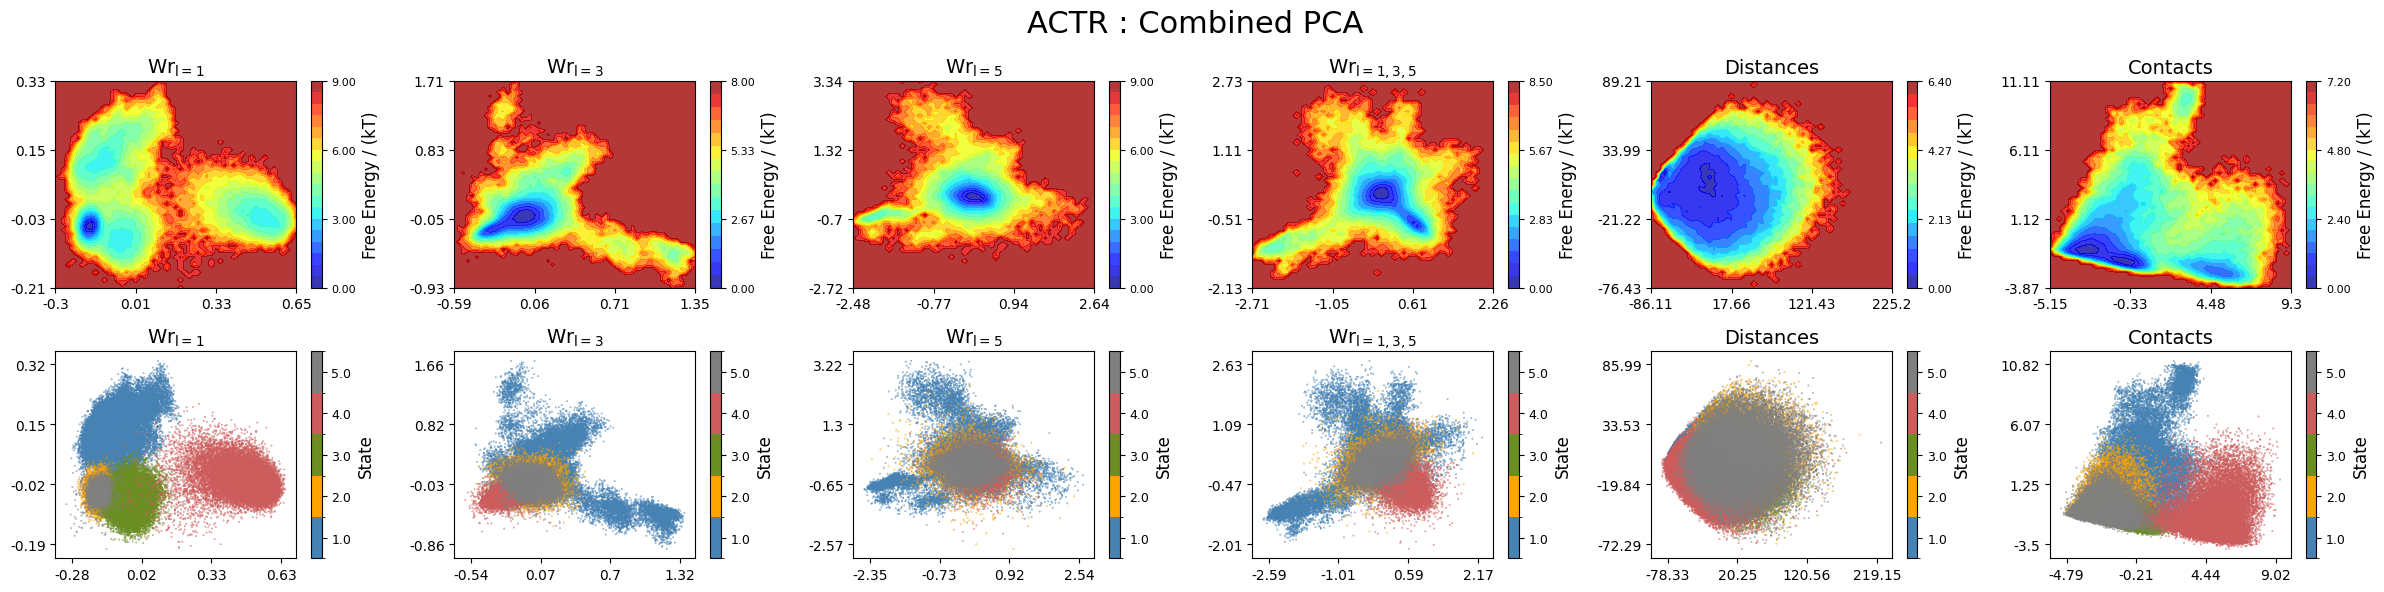

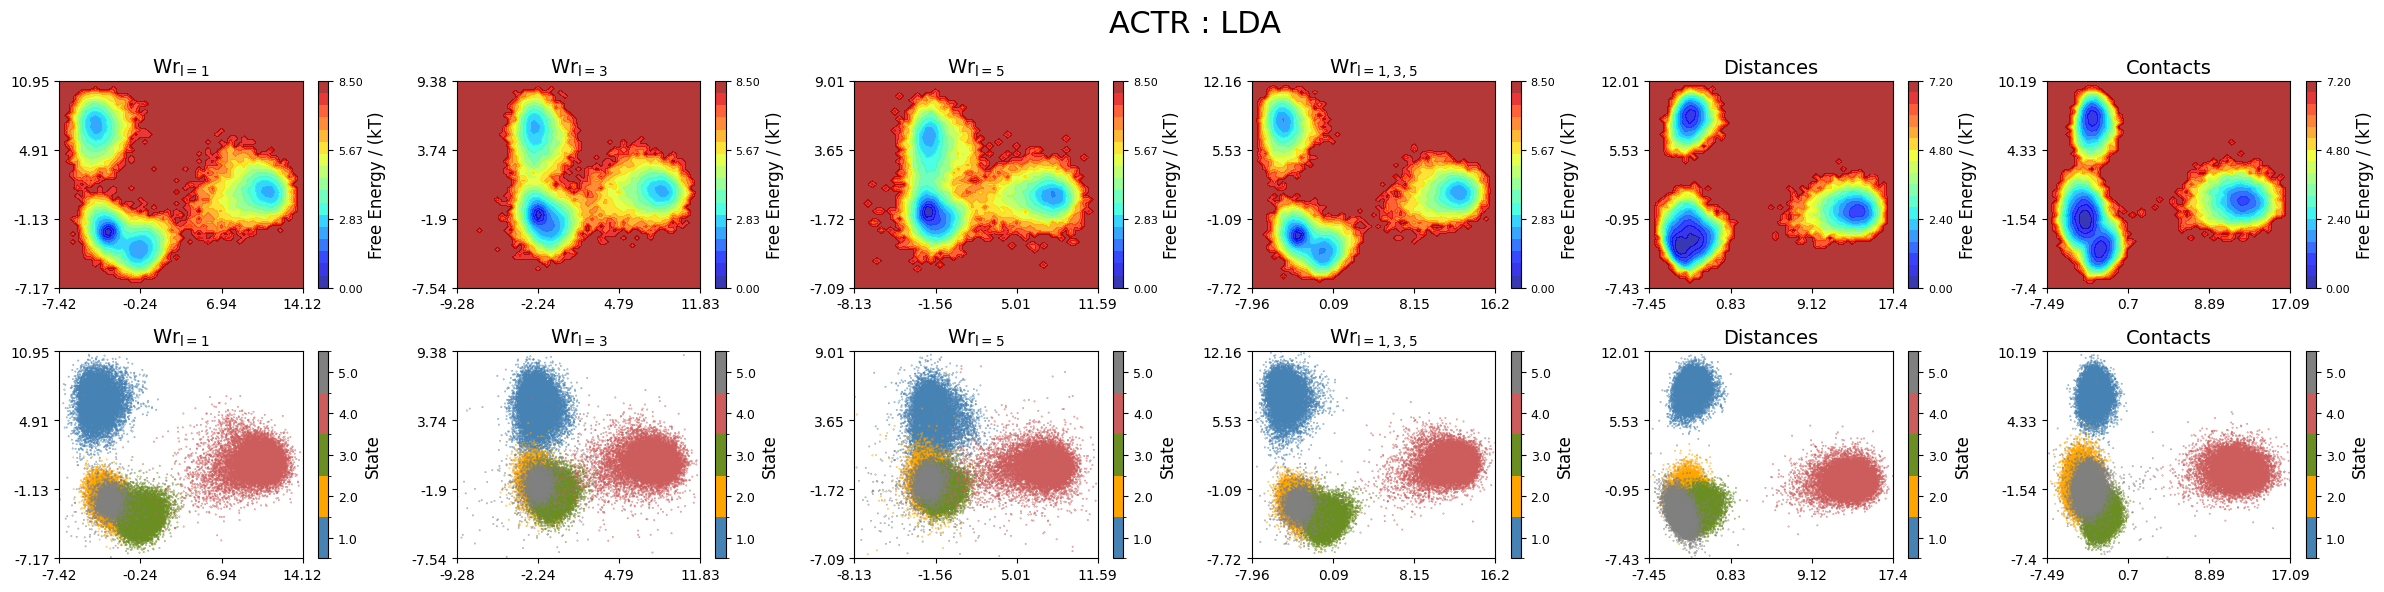

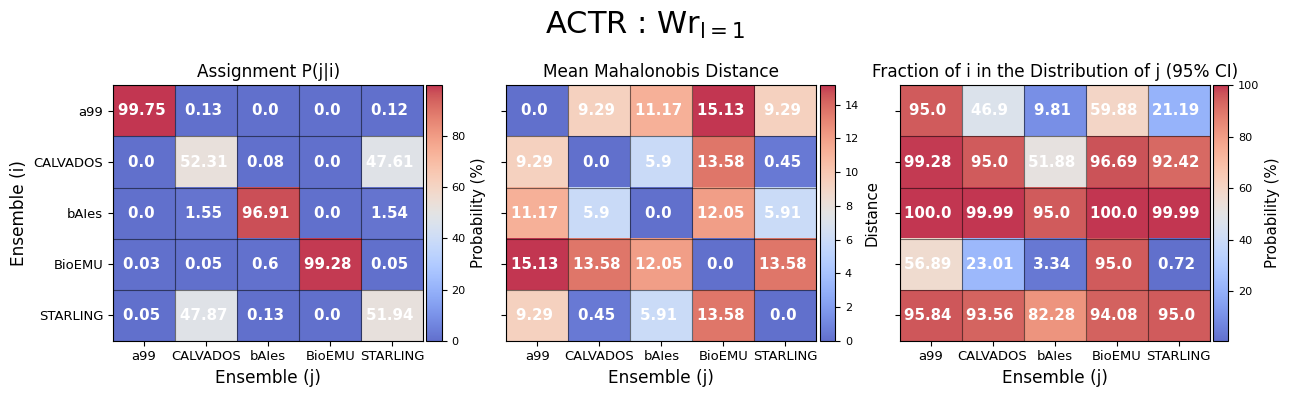

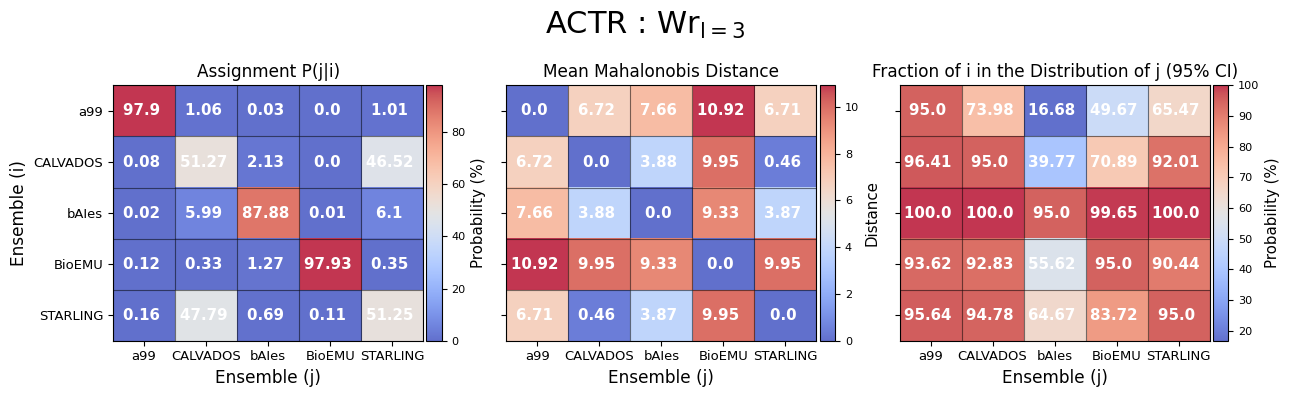

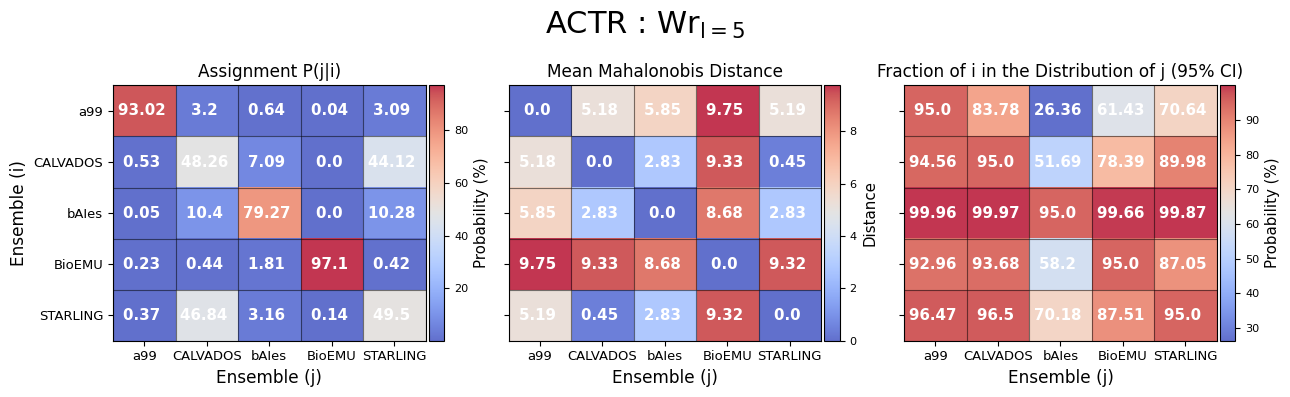

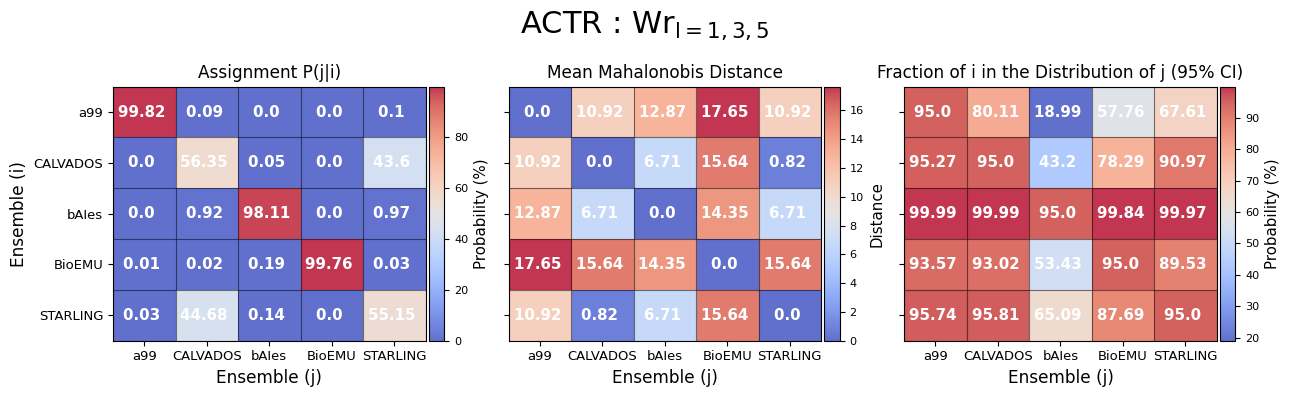

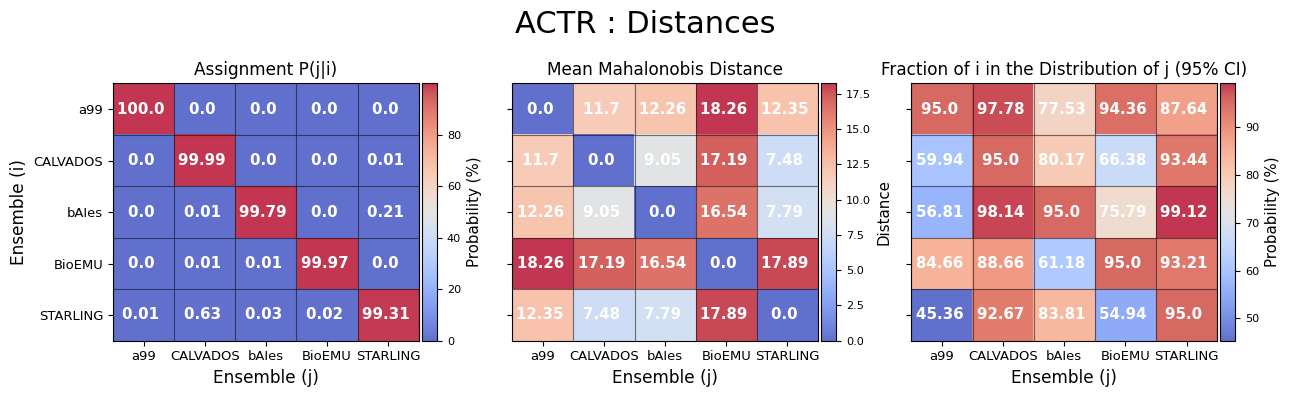

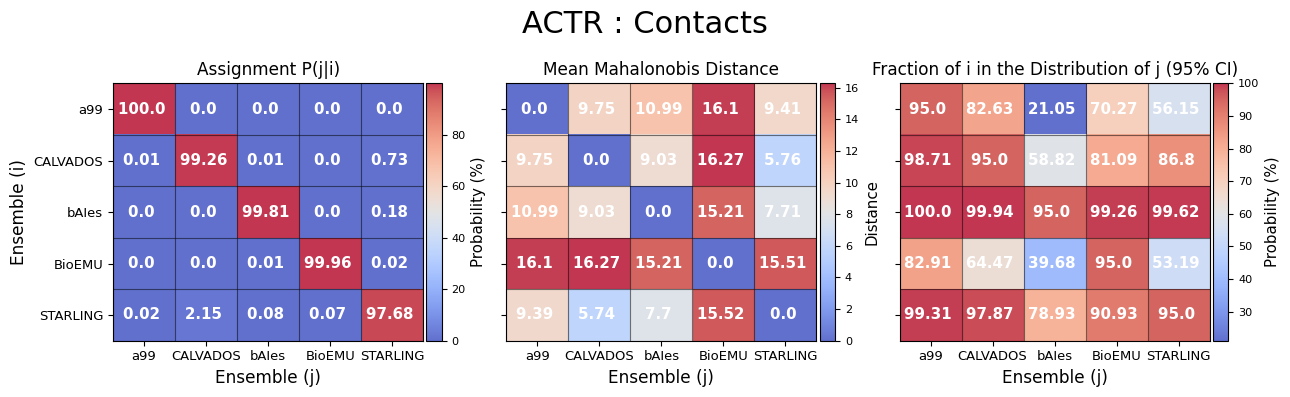

In [140]:
from writhe_tools.md_tools import to_contacts

figsize = (12, 6)
title_size = 22
scale = False
dask = True
silhouettes = []
for index, ((key, value), protein) in enumerate(zip(files.items(), protein_names[:2])):
    all_writhes = []
    all_distances = []
    silhouette = []


    fig_wr1, axes_wr1 = plt.subplots(2, 3, figsize = figsize)
    fig_wr3, axes_wr3 = plt.subplots(2, 3, figsize = figsize)
    fig_wr5, axes_wr5 = plt.subplots(2, 3, figsize = figsize)
    fig_wr13, axes_wr13 = plt.subplots(2, 3, figsize = figsize)
    fig_wr135, axes_wr135 = plt.subplots(2, 3, figsize = figsize)
    fig_d, axes_d = plt.subplots(2, 3, figsize = figsize)
    fig_c, axes_c = plt.subplots(2, 3, figsize = figsize)

    # silhouette scoring
    fig_s, axes_s = plt.subplots(2, 4, figsize = (12, 4))
    axs = axes_s.flat
    
    #fig_lda, axes_lda = plt.subplots(1, 2, figsize=(8, 3), )
    
    fig_wr_comb, axes_wr_comb = plt.subplots(2, 6, figsize=(24, 6))
    fig_lda, axes_lda = plt.subplots(2, 6, figsize=(24, 6))


    fig_wr1.suptitle(fr'{protein} : PCA $Wr_{{l=1}}$', size=title_size)
    fig_wr3.suptitle(fr'{protein} : PCA $Wr_{{l=3}}$', size=title_size)
    fig_wr5.suptitle(fr'{protein} : PCA $Wr_{{l=5}}$', size=title_size)
    fig_wr13.suptitle(fr'{protein} : PCA $Wr_{{l=1,3}}$', size=title_size)
    fig_wr135.suptitle(fr'{protein} : PCA $Wr_{{l=1,3,5}}$', size=title_size)
    fig_d.suptitle(fr'{protein} : PCA Distances', size=title_size)
    fig_c.suptitle(fr'{protein} : PCA Contacts', size=title_size)
    fig_s.suptitle(f'{protein} : Silhouette Scores', size=title_size)
    for ax, title in zip(axs[:-1], [r'PCA $Wr_{{l=1}}$', r'PCA $Wr_{{l=3}}$',
                                    r'PCA $Wr_{{l=5}}$', r'PCA $Wr_{{l=1,3}}$',
                                    r'PCA $Wr_{{l=1,3,5}}$', 'PCA Distances',
                                    'PCA Contacts']):
        ax.set_title(title)
        ax.set_xticks(np.arange(3, 15))
    
    
    fig_wr_comb.suptitle(fr'{protein} : Combined PCA', size=title_size)
    fig_lda.suptitle(fr'{protein} : LDA', size=title_size)

    

    lengths = []
    
    for pdb, dcd, axwr1, axwr3, axwr5, axwr13, axwr135, axd, axc, name, color in zip(*value.values(),
                                                                                    axes_wr1.flat,
                                                                                    axes_wr3.flat,
                                                                                    axes_wr5.flat,
                                                                                    axes_wr13.flat,      
                                                                                    axes_wr135.flat,
                                                                                    axes_d.flat,
                                                                                    axes_c.flat,
                                                                                    names,
                                                                                    colors
                                                         ):

        # if protein == protein_names[-1]:
        #     dask = True
        # else:
        #     dask = False

        s = []
        
        atom_indices = md.load(pdb).top.select('name CA')
        traj = md.load(dcd, top=pdb, atom_indices=atom_indices).center_coordinates()
        writhe = Writhe(traj.xyz)
        #features = [writhe.compute_writhe(l, cuda=True, return_self=True).features(remove_overlap=True) for l in (1, 3, 5)]
        features = [writhe.compute_writhe(l, cuda=True, return_self=True).features(remove_overlap=True) for l in (1, 3, 5)]


        distances = ResidueDistances(index_0=np.arange(traj.n_residues), traj=traj, d0=2)

        # new addition to compute score before plotting
        feature = pca(features[0], n_comp=3, dask=dask, scale=scale)[0]
        scores = silhouette_scores(feature, np.arange(3, 15), parallel=True).T
        s.append(get_best_k(scores.T))
        axs[0].plot(scores[0], scores[1], color=color, label=name, marker='.')
        fes2d(feature[:, :2], n_contours=18, alpha_contours=0.78,
              ax=axwr1, bins=55, title=name, mask=False)

        # new addition to compute score before plotting
        feature = pca(features[1], n_comp=3, dask=dask, scale=scale)[0]
        scores = silhouette_scores(feature, np.arange(3, 15), parallel=True).T
        s.append(get_best_k(scores.T))
        axs[1].plot(scores[0], scores[1], color=color, label=name, marker='.')
        fes2d(feature[:, :2],
              n_contours=18, alpha_contours=0.78, ax=axwr3, bins=55, title=name, mask=False)

        # new addition to compute score before plotting
        feature = pca(features[2], n_comp=3, dask=dask, scale=scale)[0]
        scores = silhouette_scores(feature, np.arange(3, 15), parallel=True).T
        s.append(get_best_k(scores.T))
        axs[2].plot(scores[0], scores[1], color=color, label=name, marker='.')
        
        fes2d(feature[:, :2],
              n_contours=18, alpha_contours=0.78, ax=axwr5,
              bins=55, title=name, mask=False)

        # new addition to compute score before plotting
        feature = pca(np.concatenate([pca(i, scale_projection=True, n_comp=3, dask=False)[0]
                                      for i in reindex_list(features, [0, 1])], 1),
                                      n_comp=5, dask=False)[0]
        
        scores = silhouette_scores(feature, np.arange(3, 15), parallel=True).T
        s.append(get_best_k(scores.T))
        axs[3].plot(scores[0], scores[1], color=color, label=name, marker='.')
        fes2d(feature[:, :2],
              n_contours=18, alpha_contours=0.78,
              ax=axwr13, bins=55, title=name, mask=False)

        # new addition to compute score before plotting
        feature = pca(np.concatenate([pca(i, scale_projection=True, n_comp=3, dask=False)[0]
                                      for i in reindex_list(features, [0, 1, 2])], 1),
                                      n_comp=5, dask=False)[0]
        scores = silhouette_scores(feature, np.arange(3, 15), parallel=True).T
        s.append(get_best_k(scores.T))
        axs[4].plot(scores[0], scores[1], color=color, label=name, marker='.')
        fes2d(feature[:, :2],
              n_contours=18, alpha_contours=0.78, ax=axwr135,
              bins=55, title=name, mask=False)

        # new addition to compute score before plotting
        feature = pca(distances.distances, n_comp=3, dask=dask, scale=scale)[0]
        scores = silhouette_scores(feature, np.arange(3, 15), parallel=True).T
        s.append(get_best_k(scores.T))
            
        axs[5].plot(scores[0], scores[1], color=color, label=name, marker='.')
        fes2d(feature[:, :2],
              n_contours=18, alpha_contours=0.78, ax=axd,
              bins=55, title=name, mask=False)

        # new addition to compute score before plotting
        feature = pca(sigmoid(distances.distances), n_comp=3, dask=dask, scale=scale)[0]
        scores = silhouette_scores(feature, np.arange(3, 15), parallel=True).T
        s.append(get_best_k(scores.T))
        axs[6].plot(scores[0], scores[1], color=color, label=name, marker='.')
        fes2d(feature[:, :2],
              n_contours=18, alpha_contours=0.78, ax=axc,
              bins=55, title=name, mask=False)
        
        all_writhes.append(features)
        all_distances.append(distances.distances)
        lengths.append(traj.n_frames)
        silhouette.append(s)


    del traj
    del writhe
    del distances

    n_samples = 18000 if dask else 20000

    lengths = np.array(lengths)
        
    c = np.concatenate([np.ones(i) * j for j, i in enumerate(lengths)])

    cax_fes, cax_scatter = axes_wr_comb.flat[:6], axes_wr_comb.flat[6:]
    lcax_fes, lcax_scatter = axes_lda.flat[:6], axes_lda.flat[6:]

    for fax, sax, lfax, lsax, label, selection in zip(cax_fes, cax_scatter, lcax_fes, lcax_scatter, 
                                                      (1, 3, 5, '1,3,5', 'Distances', 'Contacts'),
                                                      (0, 1, 2, [0, 1, 2], None, None)):

        if protein == protein_names[-1] and label == '1,3,5':
            continue

        if selection is not None:

            features = np.concatenate([wr[selection] if isinstance(selection, int)
                  else np.concatenate(reindex_list(wr, selection), 1) for wr in all_writhes], 0)
        else:
            features = np.concatenate(all_distances, 0)
            features = sigmoid(features) if label == 'Contacts' else features
        
        proj = pca(features, dask = True if isinstance(selection, list) or dask else False, n_comp = 2)[0]
        
        fes2d(proj[:, :2],
              n_contours=18,
              alpha_contours=0.78,
              ax=fax,
              bins=55,
              title = rf"$Wr_{{l={label}}}$" if selection is not None else label,
              mask=False
             )
        
        proj2d(proj[:, :2],
               c = c,
               state_map=True,
               cmap=cmap,
               dot_size=0.08,
               ax=sax, 
               title = rf"$Wr_{{l={label}}}$" if selection is not None else label
              )


        ###### LDA / Gauss comparison ##########


        lda = gaussian_comparison(np.array_split(features, np.cumsum(lengths)[:-1]), low_rank=True, n = n_samples)
        lda[-1] = np.concatenate(lda[-1], 0)

        proj2d(lda[-1][:, :2],
               c = np.concatenate([i * np.ones(n_samples) for i in range(5)]),
               state_map=True,
               cmap=cmap,
               dot_size=0.08,
               ax=lsax, 
               title = rf"$Wr_{{l={label}}}$" if selection is not None else label
              )

        lda_ = ci_filter(lda[-1][:, :2], ci=.9995)
        lsax.set_xlim(lda_.T[0].min(), lda_.T[0].max())
        lsax.set_ylim(lda_.T[1].min(), lda_.T[1].max())

        fes2d(ci_filter(lda[-1][:, :2], ci=.9995),
              n_contours=18,
              alpha_contours=0.78,
              extend_border=.9,
              ax=lfax,
              bins=55,
              title = rf"$Wr_{{l={label}}}$" if selection is not None else label,
              mask=False
             )

        lsax.sharex(lfax)
        lsax.sharey(lfax)

        
        fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
        fig.suptitle(fr'{protein} : '+(rf"$Wr_{{l={label}}}$" if selection is not None else label),
                     size=title_size)
        titles = ['Assignment P(j|i)', 'Mean Mahalonobis Distance', 'Fraction of i in the Distribution of j (95% CI)']
        cbar_labels = ['Probability (%)', 'Distance', 'Probability (%)']
        
        for i, (metric, ax, title, label) in enumerate(zip(lda[:-1], axes.flat, titles, cbar_labels)):
        
            annotated_matrix_plot(100 * metric if label != 'Distance' else metric,
                                  title = title,
                                  xlabel="Ensemble (j)",
                                  ylabel="Ensemble (i)" if i == 0 else '',
                                  cbar_label=label,
                                  xticks=names,
                                  yticks=names,
                                  font_scale=.27,
                                  xticks_top=False,
                                  cmap='coolwarm',
                                  hide_cbar_ticks=False,
                                  grid=True,
                                  decimals=2,
                                  alpha=.8,
                                  ax=ax
                                 )
        fig.tight_layout()

    for fig in (fig_wr1, fig_wr3, fig_wr5, fig_d,fig_c, fig_wr_comb, fig_lda, fig_wr135, fig_wr13, fig_s):
        fig.tight_layout()
        
    silhouettes.append(silhouette)

In [143]:
features = [
    r"$Wr_{l=1}$",
    r"$Wr_{l=3}$",
    r"$Wr_{l=5}$",
    r"$Wr_{l=1,3}$",
    r"$Wr_{l=1,3,5}$",
    "Distances",
    "Contacts",
]

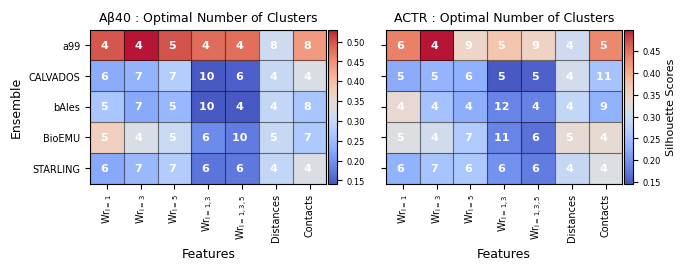

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(7, 2), sharey=True)
for i, (ax, protein) in enumerate(zip(axes.flat, protein_names[:-1])):
    
    scores = np.asarray(silhouettes[i])
    annotated_matrix_plot(scores[..., 0].astype(int), 
                          color_matrix=scores[..., 1],
                          yticks=names, xticks=features,
                          title=f'{protein} : Optimal Number of Clusters',
                         font_scale=.2, figsize=(3, 2), cbar_label='Silhouette Scores' if i else '', xticks_rotation=90, 
                         cmap='coolwarm', ylabel='Ensemble' if not i else '',
                          xlabel='Features', 
                         grid=True, alpha=.93,ax=ax)
#fig.tight_layout()

In [111]:
traj = md.load(files['ab40']['dcd'][0],
                        top=files['ab40']['pdb'][0],
                        ).center_coordinates()

atom_indices = md.load(files['ab40']['pdb'][0]).top.select('name CA')

writhe = Writhe(traj.xyz[:, atom_indices])

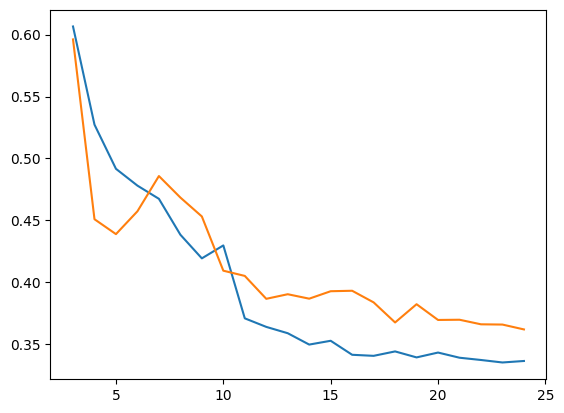

In [114]:
writhes = []
removed_writhes = []
for i in (1, 3, 5):
    writhe.compute_writhe(i, cuda=True)
    writhes.append(writhe.features())
    removed_writhes.append(writhe.features(remove_overlap=True))

proj = pca(np.concatenate([pca(i, scale_projection=True, n_comp=35, dask=False)[0] for i in writhes], 1),
           n_comp=2, dask=False)[0]

proj_rm = pca(np.concatenate([pca(i, scale_projection=True, n_comp=35, dask=False)[0] for i in removed_writhes], 1),
           n_comp=2, dask=False)[0]

scores = silhouette_scores(proj, np.arange(3, 25))
scores_rm = silhouette_scores(proj_rm, np.arange(3, 25))



In [130]:
proj_1 = pca(writhes[0], n_comp=2)[0]
scores_1 = silhouette_scores(proj_1, np.arange(3, 25))

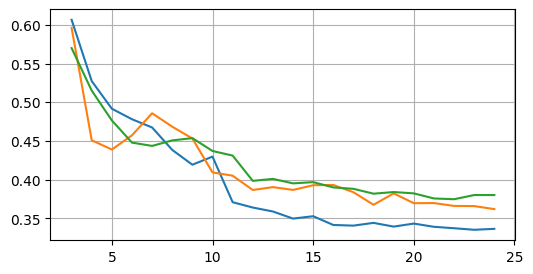

In [138]:
plt.figure(figsize=(6, 3))
plt.plot(*scores.T)
plt.plot(*scores_rm.T)
plt.plot(*scores_1.T)
plt.grid()

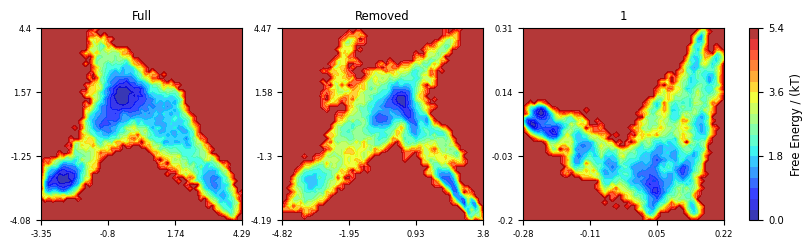

In [137]:
subplots_fes2d([proj, proj_rm, proj_1], 1, 3 , ['Full', 'Removed', '1'],
               figsize=(9, 3), bins=55, n_contours=18, share_extent=False, alpha_contours=.78)

In [57]:
gi20_from_wflat_torch(torch.from_numpy(all_writhes[0]))

tensor([[ 1.6220e+00,  5.4014e+00,  7.8713e-02,  ..., -8.8918e-03,
          2.2521e-03, -1.5873e-03],
        [ 1.5765e+00,  5.0333e+00,  1.2608e-01,  ...,  2.6961e-03,
          1.0894e-02, -5.1860e-04],
        [ 1.2662e+00,  5.0436e+00,  6.5026e-02,  ...,  7.4724e-03,
          4.2018e-03,  3.2627e-04],
        ...,
        [ 7.3788e-01,  3.0548e+00,  8.2781e-02,  ..., -2.2280e-03,
          1.0923e-03,  2.1976e-03],
        [ 5.3243e-01,  3.1295e+00,  7.3732e-02,  ..., -2.6281e-03,
          6.2921e-04,  5.9217e-04],
        [ 4.8825e-01,  3.4341e+00,  8.9390e-02,  ..., -2.5927e-03,
          3.7906e-03,  5.0299e-04]], dtype=torch.float64)

In [60]:
import torch
import torch.nn.functional as F

# ----------------------------
# Helpers
# ----------------------------

def _infer_num_segments_from_flat_len(D: int) -> int:
    # D = (S-1)(S-2)/2  <=>  S^2 - 3S + 2 - 2D = 0
    # S = (3 + sqrt(1+8D))/2
    disc = 1 + 8 * int(D)
    root = int(disc**0.5)
    if root * root != disc:
        raise ValueError(f"D={D} not compatible with (S-1)(S-2)/2; 1+8D={disc} not perfect square.")
    S = (3 + root) // 2
    if (S - 1) * (S - 2) // 2 != D:
        raise ValueError(f"D={D} did not invert cleanly to integer S.")
    return int(S)

def _shift_ij(X: torch.Tensor, di: int, dj: int) -> torch.Tensor:
    """
    Y[i,j] = X[i+di, j+dj] with out-of-range filled with 0.
    Operates on last two dims (L,L). Batch dims preserved.
    """
    *batch, L, _ = X.shape
    # slice rows
    if di >= 0:
        Y = X[..., di:, :]
        Y = F.pad(Y, (0, 0, 0, di))
    else:
        di2 = -di
        Y = X[..., :L-di2, :]
        Y = F.pad(Y, (0, 0, di2, 0))
    # slice cols
    if dj >= 0:
        Y = Y[..., :, dj:]
        Y = F.pad(Y, (0, dj, 0, 0))
    else:
        dj2 = -dj
        Y = Y[..., :, :L-dj2]
        Y = F.pad(Y, (dj2, 0, 0, 0))
    return Y

def _rev_prefix2(A: torch.Tensor) -> torch.Tensor:
    """
    P[i,j] = sum_{r=i..L-1} sum_{c=0..j} A[r,c]
    for each batch. Implemented by cumsum on cols and reversed cumsum on rows.
    """
    P = A.cumsum(dim=-1)
    P = torch.flip(P, dims=[-2]).cumsum(dim=-2)
    P = torch.flip(P, dims=[-2])
    return P

def _unflatten_W_k2(w_flat: torch.Tensor, S: int) -> torch.Tensor:
    """
    w_flat: (B,D) or (D,) with D = (S-1)(S-2)/2 corresponding to triu_indices(S,S,offset=2)
    Returns W: (B,S,S) with only upper-tri (k>=2) filled.
    """
    if w_flat.ndim == 1:
        w_flat = w_flat.unsqueeze(0)
    B, D = w_flat.shape

    iu, ju = torch.triu_indices(S, S, offset=2, device=w_flat.device)
    if iu.numel() != D:
        raise ValueError(f"Expected D={iu.numel()} for S={S}, got D={D}.")

    flat_idx = (iu * S + ju).unsqueeze(0).expand(B, -1)  # (B,D)
    W = torch.zeros((B, S * S), device=w_flat.device, dtype=w_flat.dtype)
    W.scatter_(1, flat_idx, w_flat)
    W = W.view(B, S, S)
    return W

# ----------------------------
# Main: 20 invariants in torch (no i/j loops)
# ----------------------------

def gi_20_from_flat_torch(w_flat: torch.Tensor) -> torch.Tensor:
    """
    Returns (B,20) (or (20,) if input is (D,))
    Order matches the paper’s list used in your numpy code:

      0  I12
      1  Ia12
      2  I1324
      3  I1234
      4  I1423
      5  I123456
      6  I123546
      7  I123645
      8  I132456
      9  I132546
     10  I132645
     11  I142356
     12  I142536
     13  I142635
     14  I152346
     15  I152436
     16  I152634
     17  I162345
     18  I162435
     19  I162534
    """
    single = (w_flat.ndim == 1)
    if single:
        w_flat_in = w_flat.unsqueeze(0)
    else:
        w_flat_in = w_flat

    B, D = w_flat_in.shape
    S = _infer_num_segments_from_flat_len(D)  # number of segments (Nres-1)
    W = _unflatten_W_k2(w_flat_in, S)         # (B,S,S)

    L = S
    device = W.device
    dtype = W.dtype

    # Mask used in the "full_aid" matmuls: keep b <= j-2  (row=b, col=j)
    mask_b_le_jm2 = torch.tril(torch.ones((L, L), device=device, dtype=dtype), diagonal=-2)

    # ---- Order-1 interval sums J = I12(i,j) as DP, vectorized
    J = _rev_prefix2(W)                       # (B,L,L)
    J_end = J[..., -1]                        # (B,L)

    # convenience shifts
    J_i1     = _shift_ij(J,  +1,  0)
    J_jm1    = _shift_ij(J,   0, -1)
    J_i1_jm1 = _shift_ij(J,  +1, -1)

    # vectors "next index" (x[j+1]) for columns
    def _col_next(v: torch.Tensor) -> torch.Tensor:
        # v: (B,L) -> (B,L) with v_next[:,j] = v[:,j+1], last col 0
        return torch.cat([v[:, 1:], torch.zeros((B, 1), device=v.device, dtype=v.dtype)], dim=1)

    # ---- Order-2 (3 invariants) as rev-prefix sums of base matrices
    coef_J_end_next_col = _col_next(J_end)                         # (B,L)
    A1234 = W * coef_J_end_next_col[:, None, :]                    # W[i,j]*I12[j+1,END]
    I1234 = _rev_prefix2(A1234)

    A1423 = W * J_i1_jm1                                           # W[i,j]*I12[i+1,j-1]
    I1423 = _rev_prefix2(A1423)

    A1324 = W * ( _col_next(J_end)[:, :, None] - J_i1 - J_end[:, None, :] )
    # Explanation: (I12[i+1,END] - I12[i+1,j] - I12[j,END]) * W[i,j]
    I1324 = _rev_prefix2(A1324)

    # ---- "full" auxiliaries for order-3
    # I1234_full_aid[i,j] = sum_{b <= j-2} W[i,b] * I12[b+1, j]
    M1 = _shift_ij(J, +1, 0) * mask_b_le_jm2                       # (B,L,L) rows=b, cols=j
    I1234_full_aid = torch.matmul(W, M1)                           # (B,L,L)

    # I1324_full_aid[i,j] = sum_{b <= j-2} W[i,b] * I12[b, j]
    M2 = J * mask_b_le_jm2
    I1324_full_aid = torch.matmul(W, M2)                           # (B,L,L)

    # I1234_full = revprefix( aid[i,j] - aid[i,j-1] )
    d1234 = I1234_full_aid - _shift_ij(I1234_full_aid, 0, -1)
    I1234_full = _rev_prefix2(d1234)

    # I1324_full = revprefix( (aid[i,j-1]-aid[i,j]) + (J[i,j-1]-J[i+1,j-1])*(J[i+1,j]-J[i+1,j-1]) )
    term1 = _shift_ij(I1324_full_aid, 0, -1) - I1324_full_aid
    diffA = J_jm1 - J_i1_jm1
    diffB = J_i1 - J_i1_jm1
    I1324_full = _rev_prefix2(term1 + diffA * diffB)

    # I1423_full0 = revprefix( (J[i+1,j-1]-J[i+1,j])*(J[i+1,END]-J[i+1,j]-J[i,END]+J[i,j]) )
    base0 = (J_i1_jm1 - J_i1) * (_col_next(J_end)[:, :, None] - J_i1 - J_end[:, None, :] + J)
    I1423_full0 = _rev_prefix2(base0)

    # ---- full2 auxiliaries (suffix sums along k), fully vectorized via matmuls/decompositions

    row_sum = W.sum(dim=-1)                                        # (B,L)

    # For I1324_full2_aid[a,k]:
    # S1[a,k] = sum_m J[a,m] * W[k,m+1]
    J_left = J[..., :-1]                                           # (B,L,L-1) columns m=0..L-2
    W_right = W[..., 1:]                                           # (B,L,L-1) columns c=1..L-1
    S1 = torch.matmul(J_left, W_right.transpose(-2, -1))           # (B,L,L) (a,k)

    S1_diag = torch.diagonal(S1, dim1=-2, dim2=-1)                 # (B,L) gives sum_c W[k,c]*J[k,c-1]
    I1324_full2_aid = S1 - J * row_sum[:, None, :] - S1_diag[:, None, :]

    # suffix sum along k (last dim)
    I1324_full2 = torch.flip(torch.cumsum(torch.flip(I1324_full2_aid, dims=[-1]), dim=-1), dims=[-1])

    # For I1423_full2_aid[a,k]:
    # termC[a,k] = sum_c J[a,c]*W[k,c]  => (J @ W^T)
    termC = torch.matmul(J, W.transpose(-2, -1))                   # (B,L,L)
    termB = torch.diagonal(termC, dim1=-2, dim2=-1)                # (B,L) = sum_c J[k,c]*W[k,c]
    termA = (J_end[:, :, None] - J_end[:, None, :]) * row_sum[:, None, :]  # (B,L,L) (a,k)
    I1423_full2_aid = termA + termB[:, None, :] - termC
    I1423_full2 = torch.flip(torch.cumsum(torch.flip(I1423_full2_aid, dims=[-1]), dim=-1), dims=[-1])

    # ---- Order-3 (15 invariants) as revprefix of base matrices

    # helpful ends
    I1234_end = I1234[..., -1]
    I1324_end = I1324[..., -1]
    I1423_end = I1423[..., -1]

    # group (12)**
    I123456 = _rev_prefix2(W * _col_next(I1234_end)[:, None, :])
    I123546 = _rev_prefix2(W * _col_next(I1324_end)[:, None, :])
    I123645 = _rev_prefix2(W * _col_next(I1423_end)[:, None, :])

    # I132456
    base_132456 = W * (_col_next(I1234_end)[:, :, None] - _shift_ij(I1234, +1, 0) - I1234_end[:, None, :])
    I132456 = _rev_prefix2(base_132456)

    # I142356
    I142356 = _rev_prefix2(W * (J_i1_jm1 * coef_J_end_next_col[:, None, :]))

    # I152346
    base_152346 = W * (_shift_ij(I1234, +1, -1) - _shift_ij(I1234_full, +1, 0) - (J_end[:, None, :] * J_i1_jm1))
    I152346 = _rev_prefix2(base_152346)

    # I152436
    base_152436 = W * (_shift_ij(I1324, +1, -1) - _shift_ij(I1324_full, +1, 0))
    I152436 = _rev_prefix2(base_152436)

    # I152634
    base_152634 = W * (_shift_ij(I1423_full0, +1, -1) - _shift_ij(I1423, +1, 0))
    I152634 = _rev_prefix2(base_152634)

    # I162345 / I162435 / I162534
    I162345 = _rev_prefix2(W * _shift_ij(I1234_full, +1, -1))
    I162435 = _rev_prefix2(W * _shift_ij(I1324_full, +1, -1))
    I162534 = _rev_prefix2(W * _shift_ij(I1423, +1, -1))

    # lagged block (vectorized “stored at i+1” is naturally handled by shifts)

    I132546 = _rev_prefix2(W * (_shift_ij(I1324_full2, +1, +1) - I1324_full[..., -1][:, None, :]))
    I132645 = _rev_prefix2(W * (_shift_ij(I1423_full2, +1, +1) - I1423_end[:, None, :]))

    base_142536 = W * (_col_next(I1324_full[..., -1])[:, :, None] - _shift_ij(I1324, +1, 0) - _shift_ij(I1324_full2, +1, 0))
    I142536 = _rev_prefix2(base_142536)

    base_142635 = W * (_col_next(I1423_end)[:, :, None] - _shift_ij(I1423_full2, +1, 0) - _shift_ij(I1423_full0, +1, 0))
    I142635 = _rev_prefix2(base_142635)

    # ---- collect 20 totals at (i=0, j=L-1)
    i0, jL = 0, L - 1

    I12_total   = J[:, i0, jL]
    Ia12_total  = W.abs().sum(dim=(-2, -1))   # since W already only has upper (k>=2)

    out = torch.stack([
        I12_total,
        Ia12_total,
        I1324[:, i0, jL],
        I1234[:, i0, jL],
        I1423[:, i0, jL],
        I123456[:, i0, jL],
        I123546[:, i0, jL],
        I123645[:, i0, jL],
        I132456[:, i0, jL],
        I132546[:, i0, jL],
        I132645[:, i0, jL],
        I142356[:, i0, jL],
        I142536[:, i0, jL],
        I142635[:, i0, jL],
        I152346[:, i0, jL],
        I152436[:, i0, jL],
        I152634[:, i0, jL],
        I162345[:, i0, jL],
        I162435[:, i0, jL],
        I162534[:, i0, jL],
    ], dim=-1)

    return out[0] if single else out


# Keep your old public name if you want it (returns 20, NOT 30; no padding)
def gisa(w_flat):
    if not torch.is_tensor(w_flat):
        w_flat = torch.as_tensor(w_flat)
    return gi_20_from_flat_torch(w_flat).numpy()

In [62]:
gisas = [gisa(i) for i in all_writhes]
lengths = np.fromiter(map(len, gisas), int)
proj = pca(np.concatenate(gisas, 0))[0]

In [67]:
projs = [pca(i)[0][:, :2] for i in gisas]

NameError: name 'names' is not defined

/home/t/writhe/Writhe_Package_Lite/src/writhe_tools/plots.py:715: RuntimeWarning: divide by zero encountered in log
  F = -np.log(counts)
/home/t/writhe/Writhe_Package_Lite/src/writhe_tools/plots.py:715: RuntimeWarning: divide by zero encountered in log
  F = -np.log(counts)
/home/t/writhe/Writhe_Package_Lite/src/writhe_tools/plots.py:715: RuntimeWarning: divide by zero encountered in log
  F = -np.log(counts)
/home/t/writhe/Writhe_Package_Lite/src/writhe_tools/plots.py:715: RuntimeWarning: divide by zero encountered in log
  F = -np.log(counts)
/home/t/writhe/Writhe_Package_Lite/src/writhe_tools/plots.py:715: RuntimeWarning: divide by zero encountered in log
  F = -np.log(counts)
/home/t/writhe/Writhe_Package_Lite/src/writhe_tools/plots.py:715: RuntimeWarning: divide by zero encountered in log
  F = -np.log(counts)


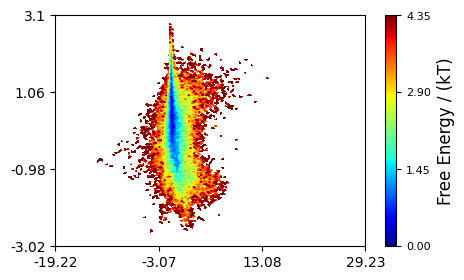

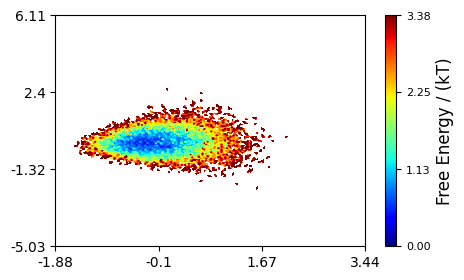

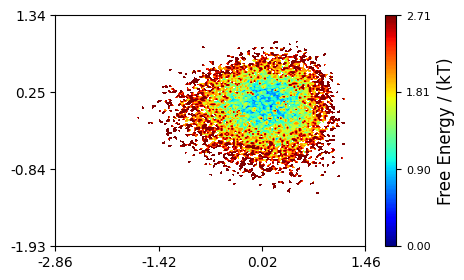

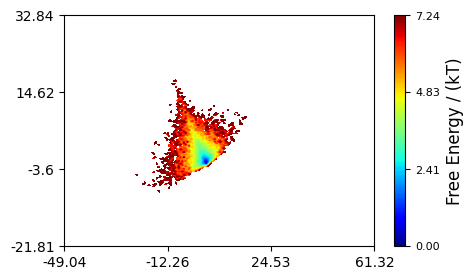

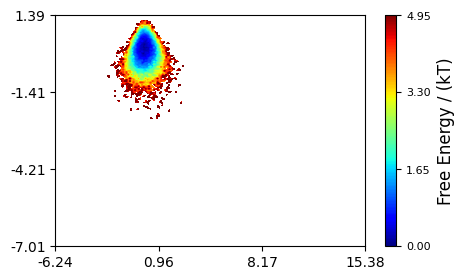

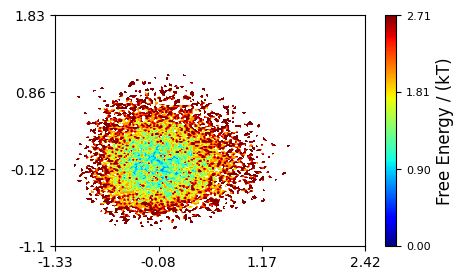

In [68]:
for i in projs:
    fes2d(i)
    

/home/t/writhe/Writhe_Package_Lite/src/writhe_tools/plots.py:715: RuntimeWarning: divide by zero encountered in log
  F = -np.log(counts)


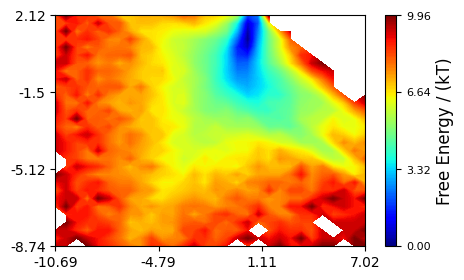

In [65]:
from writhe_tools.plots import fes2d
from tools import ci_filter
fes2d(ci_filter(proj[:, :2]), bins=30 )

In [39]:
all_writhes

[array([[-0.00491362, -0.0003457 ,  0.01044006, ..., -0.01290073,
          0.04186554,  0.06178401],
        [-0.00364193, -0.000509  ,  0.0076023 , ..., -0.01659152,
          0.06130097,  0.07714161],
        [-0.01639005,  0.00820207,  0.0106287 , ..., -0.00101026,
          0.04634311,  0.0632372 ],
        ...,
        [-0.02532732, -0.00773701,  0.00241503, ..., -0.01359933,
          0.0024564 , -0.0159777 ],
        [-0.03533553, -0.01157566,  0.00166463, ..., -0.01645032,
         -0.00448945, -0.02189202],
        [-0.02461527, -0.01265483, -0.00303797, ..., -0.01924667,
         -0.01489291, -0.02392026]], dtype=float32),
 array([[-0.0394079 , -0.01655192, -0.00799351, ..., -0.02654153,
          0.00980065,  0.08452849],
        [-0.00221328,  0.0160846 , -0.00512277, ...,  0.06442259,
          0.02234337, -0.02399918],
        [-0.01699249,  0.00585146, -0.00246719, ...,  0.00741593,
          0.0024542 ,  0.01305354],
        ...,
        [ 0.02555365, -0.0048648 ,  0.0